In [25]:
# -*- coding: utf-8 -*-
import os
import geopandas as gpd
import pandas as pd
from shapely.geometry import LineString, Point
from fiona import listlayers
import folium

# ---------- INPUT ----------
LAYER = None  # якщо None — візьмемо перший шар із GPKG

# гідропост/рівні
NULL_POSTA_BALT = 592.11     # нуль поста (Балт-77)
BALT_TO_EVRS    = 0.105      # зсув Балт-77 -> EVRS
MAX_LEVEL_CM    = 560        # 560 см

post_zero_evrs_m = NULL_POSTA_BALT + BALT_TO_EVRS
max_level_add_m  = MAX_LEVEL_CM / 100.0
H_max_evrs_m     = post_zero_evrs_m + max_level_add_m
# ---------- OUTPUT ----------
OUT_POINTS = "/mnt/c/Users/5302/PycharmProjects/geoid/profile_points_evrs.geojson"
OUT_LINE   = "/mnt/c/Users/5302/PycharmProjects/geoid/profile_line_evrs.geojson"
OUT_COMBO  = "/mnt/c/Users/5302/PycharmProjects/geoid/profile_combined_evrs.geojson"
OUT_HTML   = "/mnt/c/Users/5302/PycharmProjects/geoid/profile_map.html"

# ---------- READ ----------
# визначимо шар, якщо не заданий
if LAYER is None:
    LAYER = listlayers(GPKG_PATH)[0]

gdf = gpd.read_file(GPKG_PATH, layer=LAYER)
if gdf.crs is None:
    gdf = gdf.set_crs(4326)
else:
    gdf = gdf.to_crs(4326)

# сортуємо по порядку, щоб лінія була правильна
order_cols = [c for c in gdf.columns if c.lower() in ("distance_m","dist_m","order","idx","id","seq","sequence")]
if order_cols:
    gdf = gdf.sort_values(order_cols[0]).reset_index(drop=True)

# ---------- EVRS для профілю ----------
# якщо elevation_evrs_m ще нема — додаємо (тільки до профілю)
if "elevation_evrs_m" not in gdf.columns:
    if "elevation_m" not in gdf.columns:
        raise ValueError("У шарі немає 'elevation_m' для перерахунку в EVRS.")
    gdf["elevation_evrs_m"] = gdf["elevation_m"] + BALT_TO_EVRS



# додамо ці значення у кожну точку для зручності фронтенду
gdf["post_zero_evrs_m"] = post_zero_evrs_m
gdf["max_level_add_m"]  = max_level_add_m
gdf["H_max_evrs_m"]     = H_max_evrs_m
gdf["vertical_datum"]   = "EVRS"
gdf["kind"]             = "profile_point"

# ---------- LINESTRING профілю ----------
line = LineString([pt for pt in gdf.geometry])
gdf_line = gpd.GeoDataFrame(
    {
        "post_zero_evrs_m": [post_zero_evrs_m],
        "max_level_add_m":  [max_level_add_m],
        "H_max_evrs_m":     [H_max_evrs_m],
        "vertical_datum":   ["EVRS"],
        "kind":             ["profile_line"],
    },
    geometry=[line],
    crs="EPSG:4326",
)

# ---------- SAVE ----------
gdf.to_file(OUT_POINTS, driver="GeoJSON")
gdf_line.to_file(OUT_LINE, driver="GeoJSON")
pd.concat([gdf, gdf_line], ignore_index=True).to_file(OUT_COMBO, driver="GeoJSON")

print("[OK] Saved:")
print("  points →", os.path.abspath(OUT_POINTS))
print("  line   →", os.path.abspath(OUT_LINE))
print("  combo  →", os.path.abspath(OUT_COMBO))

# ---------- QUICK PREVIEW ----------
print("\n[HEAD]")
print(gdf[["distance_m","elevation_m","elevation_evrs_m","H_max_evrs_m"]].head())
print("\n[BOUNDS WGS84]", gdf.total_bounds)

# ---------- INTERACTIVE MAP (open profile_map.html) ----------
# центр карти
cent_lat = float(gdf.geometry.y.mean())
cent_lon = float(gdf.geometry.x.mean())
m = folium.Map(location=[cent_lat, cent_lon], zoom_start=16, tiles="CartoDB positron")

# лінія профілю
folium.GeoJson(
    gdf_line.to_json(),
    name="profile line",
    style_function=lambda x: {"color": "#1f77b4", "weight": 3},
    tooltip=folium.GeoJsonTooltip(fields=["H_max_evrs_m", "post_zero_evrs_m"])
).add_to(m)

# точки профілю (popup з висотами)
for row in gdf.itertuples():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3,
        color="#ff7f0e",
        fill=True, fill_opacity=0.8,
        popup=(
            f"dist={getattr(row,'distance_m',None)} м<br>"
            f"elev (Balt77)={row.elevation_m:.3f} м<br>"
            f"elev (EVRS)={row.elevation_evrs_m:.3f} м<br>"
            f"H_max (EVRS)={row.H_max_evrs_m:.3f} м"
        )
    ).add_to(m)

folium.LayerControl().add_to(m)
m.save(OUT_HTML)
print("[OK] Map →", os.path.abspath(OUT_HTML))


[OK] Saved:
  points → /mnt/c/Users/5302/PycharmProjects/geoid/profile_points_evrs.geojson
  line   → /mnt/c/Users/5302/PycharmProjects/geoid/profile_line_evrs.geojson
  combo  → /mnt/c/Users/5302/PycharmProjects/geoid/profile_combined_evrs.geojson

[HEAD]
   distance_m  elevation_m  elevation_evrs_m  H_max_evrs_m
0       0.000      598.302           598.407       597.815
1       1.154      598.153           598.258       597.815
2       3.202      597.309           597.414       597.815
3       5.082      597.264           597.369       597.815
4       6.081      595.786           595.891       597.815

[BOUNDS WGS84] [24.91224 48.01641 24.9128  48.01673]
[OK] Map → /mnt/c/Users/5302/PycharmProjects/geoid/profile_map.html


[OK] saved:
  CSV    -> /mnt/c/Users/5302/PycharmProjects/geoid/hyd_out/hydraulic_metrics_vs_profile.csv
  plots  -> /mnt/c/Users/5302/PycharmProjects/geoid/hyd_out/overlay_profile_dem.png , /mnt/c/Users/5302/PycharmProjects/geoid/hyd_out/overlay_depths.png


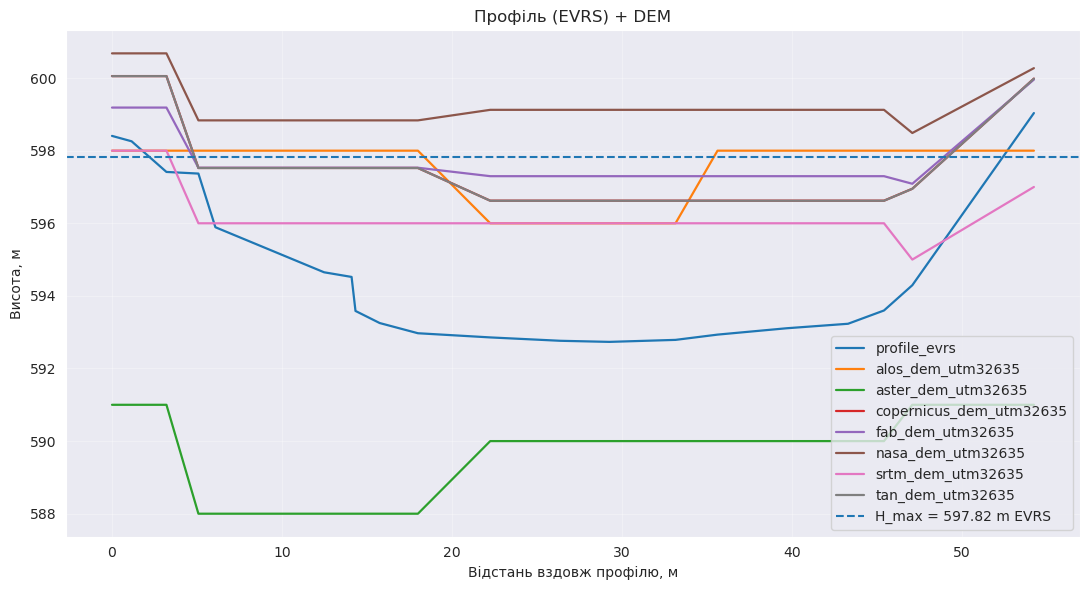

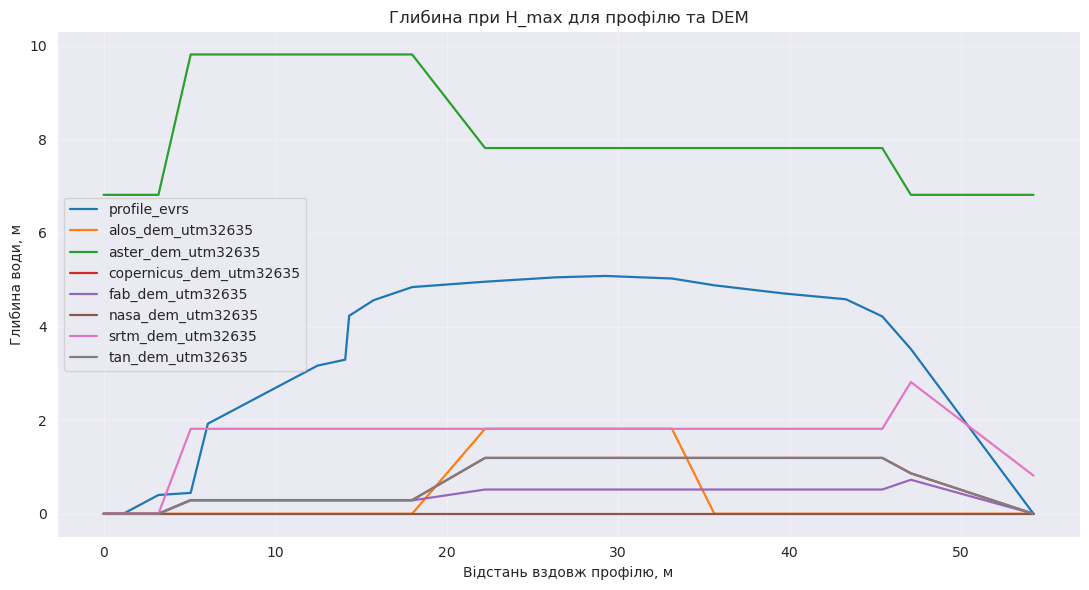

In [26]:
# -*- coding: utf-8 -*-
import os, glob, math, unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

# -------- INPUT --------
PROFILE_GEOJSON = r"/mnt/c/Users/5302/PycharmProjects/geoid/profile_combined_evrs.geojson"
DEM_DIR = Path(r"/mnt/d/paper_data/DEM_DATA/data/DATA_UTM/dem")
DEM_PATTERNS = {
    "alos_dem_utm32635":       "*alos*dem*32635*.tif",
    "aster_dem_utm32635":      "*aster*dem*32635*.tif",
    "copernicus_dem_utm32635": "*copernicus*dem*32635*.tif",
    "fab_dem_utm32635":        "*fab*dem*32635*.tif",
    "nasa_dem_utm32635":       "*nasa*dem*32635*.tif",
    "srtm_dem_utm32635":       "*srtm*dem*32635*.tif",
    "tan_dem_utm32635":        "*tan*dem*32635*.tif",
}

# -------- OUTPUT --------
OUT_DIR = Path("/mnt/c/Users/5302/PycharmProjects/geoid/hyd_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV         = OUT_DIR / "hydraulic_metrics_vs_profile.csv"
OUT_OVERLAY_PNG = OUT_DIR / "overlay_profile_dem.png"
OUT_DEPTHS_PNG  = OUT_DIR / "overlay_depths.png"

# ---------- helpers ----------
def _normalize_name(s: str) -> str:
    return unicodedata.normalize("NFKC", s).lower()

def discover_dems(base_dir: Path, patterns: dict) -> dict:
    all_tifs = [Path(p) for p in glob.glob(str(base_dir/"*.tif"))]
    result = {}
    for label, pat in patterns.items():
        cand = [Path(p) for p in glob.glob(str(base_dir/pat))]
        if not cand:
            desired = _normalize_name(label)
            for p in all_tifs:
                if all(tok in _normalize_name(p.name) for tok in desired.split("_")):
                    cand.append(p)
        if cand:
            result[label] = str(cand[0])
    return result

def sample_raster_at_lonlat(dem_path, lons, lats):
    with rasterio.open(dem_path) as src:
        pts = gpd.GeoSeries(gpd.points_from_xy(lons, lats), crs="EPSG:4326").to_crs(src.crs)
        xs, ys = pts.x.to_numpy(), pts.y.to_numpy()
        vals = list(src.sample(zip(xs, ys)))
        arr = np.array([v[0] if len(v)>0 else np.nan for v in vals], float)
        if src.nodata is not None:
            arr = np.where(np.isclose(arr, src.nodata), np.nan, arr)
    return arr

def wetted_metrics(x, z, H):
    x = np.asarray(x, float); z = np.asarray(z, float)
    d = np.maximum(H - z, 0.0)
    A = np.trapz(d, x)
    W = 0.0; P = 0.0
    for i in range(len(x)-1):
        x0, x1 = x[i], x[i+1]; z0, z1 = z[i], z[i+1]
        dx = x1 - x0
        below0, below1 = (z0 < H), (z1 < H)
        if below0 and below1:
            W += dx
            P += math.hypot(dx, z1 - z0)
        elif below0 and not below1:
            t = float(np.clip((H - z0)/(z1 - z0), 0.0, 1.0))
            W += dx * t
            dz = (z0 + t*(z1 - z0)) - z0
            P += math.hypot(dx*t, dz)
        elif not below0 and below1:
            t = float(np.clip((H - z0)/(z1 - z0), 0.0, 1.0))
            W += dx * (1 - t)
            dz = z1 - (z0 + t*(z1 - z0))
            P += math.hypot(dx*(1 - t), dz)
    D_mean = A/W if W>0 else 0.0
    R = A/P if P>0 else 0.0
    return A, P, W, D_mean, R

# ---------- read profile points (EVRS already) ----------
gdf = gpd.read_file(PROFILE_GEOJSON)
gdf = gdf.to_crs(4326)
pts = gdf[gdf.get("kind").fillna("profile_point") == "profile_point"].copy()
pts = pts.dropna(subset=["distance_m","elevation_evrs_m"])
pts = pts.sort_values("distance_m").reset_index(drop=True)

x   = pts["distance_m"].to_numpy(float)
z_p = pts["elevation_evrs_m"].to_numpy(float)
lon = pts.geometry.x.to_numpy(float)
lat = pts.geometry.y.to_numpy(float)
H   = float(pts["H_max_evrs_m"].iloc[0])  # однакове для всіх точок

# ---------- sample DEMs ----------
dems = discover_dems(DEM_DIR, DEM_PATTERNS)
series = {"profile_evrs": z_p}
for name, path in dems.items():
    series[name] = sample_raster_at_lonlat(path, lon, lat)

# ---------- plots ----------
plt.figure(figsize=(11,6))
for name, z in series.items():
    plt.plot(x, z, label=name, linewidth=1.6)
plt.axhline(H, ls="--", lw=1.5, label=f"H_max = {H:.2f} m EVRS")
plt.xlabel("Відстань вздовж профілю, м"); plt.ylabel("Висота, м")
plt.title("Профіль (EVRS) + DEM")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(OUT_OVERLAY_PNG, dpi=160)

plt.figure(figsize=(11,6))
for name, z in series.items():
    d = np.maximum(H - np.asarray(z,float), 0.0)
    plt.plot(x, d, label=name, linewidth=1.6)
plt.xlabel("Відстань вздовж профілю, м"); plt.ylabel("Глибина води, м")
plt.title("Глибина при H_max для профілю та DEM")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(OUT_DEPTHS_PNG, dpi=160)

# ---------- metrics & errors ----------
def rmse(a, b, mask=None):
    a = np.asarray(a, float); b = np.asarray(b, float)
    if mask is not None: a, b = a[mask], b[mask]
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0: return np.nan
    return float(np.sqrt(np.mean((a[m]-b[m])**2)))

rows = []
A0,P0,W0,D0,R0 = wetted_metrics(x, z_p, H)
rows.append({"name":"profile_evrs","A_m2":A0,"P_m":P0,"W_m":W0,"D_mean_m":D0,"R_m":R0,
             "dA_vs_profile":0.0,"dP_vs_profile":0.0,"rel_dA_%":0.0,"rel_dP_%":0.0,
             "RMSE_all_m":0.0,"RMSE_underwater_m":0.0})

mask_under = z_p < H

for name, z in series.items():
    if name == "profile_evrs":
        continue
    A,P,W,D,R = wetted_metrics(x, z, H)
    rows.append({
        "name": name,
        "A_m2": A, "P_m": P, "W_m": W, "D_mean_m": D, "R_m": R,
        "dA_vs_profile": A - A0,
        "dP_vs_profile": P - P0,
        "rel_dA_%": (A - A0)/A0*100 if A0>0 else np.nan,
        "rel_dP_%": (P - P0)/P0*100 if P0>0 else np.nan,
        "RMSE_all_m": rmse(z, z_p),
        "RMSE_underwater_m": rmse(z, z_p, mask=mask_under)
    })

pd.DataFrame(rows).sort_values("name").to_csv(OUT_CSV, index=False)

print("[OK] saved:")
print("  CSV    ->", OUT_CSV)
print("  plots  ->", OUT_OVERLAY_PNG, ",", OUT_DEPTHS_PNG)

In [28]:
# -*- coding: utf-8 -*-
import os, glob, unicodedata
from pathlib import Path
import numpy as np
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.mask import mask
from rasterio.features import shapes
from shapely.geometry import shape, LineString
from shapely.ops import unary_union

# ========= INPUTS =========
PROFILE_GEOJSON = r"/mnt/c/Users/5302/PycharmProjects/geoid/profile_combined_evrs.geojson"

DEM_DIR = Path(r"/mnt/d/paper_data/DEM_DATA/data/DATA_UTM/dem")
DEM_PATTERNS = {
    "alos_dem_utm32635":       "*alos*dem*32635*.tif",
    "aster_dem_utm32635":      "*aster*dem*32635*.tif",
    "copernicus_dem_utm32635": "*copernicus*dem*32635*.tif",
    "fab_dem_utm32635":        "*fab*dem*32635*.tif",
    "nasa_dem_utm32635":       "*nasa*dem*32635*.tif",
    "srtm_dem_utm32635":       "*srtm*dem*32635*.tif",
    "tan_dem_utm32635":        "*tan*dem*32635*.tif",
}

# Буфер коридору (метрів) навколо лінії профілю, в межах якого рахуємо затоплення
BUFFER_M = 200.0
# Мінімальна площа полігону, щоб прибирати "сміття" (м²)
MIN_POLY_M2 = 50.0

# Якщо знаєш вертикальні зсуви DEM до EVRS (м), запиши тут:
DEM_VERTICAL_OFFSETS = {
    # "aster_dem_utm32635": +0.0,
    # "copernicus_dem_utm32635": -0.5,
}

# ========= OUTPUTS =========
OUT_DIR = Path("/mnt/c/Users/5302/PycharmProjects/geoid/flood_area_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV = OUT_DIR / "flood_area_by_dem.csv"
OUT_POLY_DIR = OUT_DIR / "polygons"
OUT_POLY_DIR.mkdir(exist_ok=True)

# ========= HELPERS =========
def _normalize_name(s: str) -> str:
    import unicodedata
    return unicodedata.normalize("NFKC", s).lower()

def discover_dems(base_dir: Path, patterns: dict) -> dict:
    all_tifs = [Path(p) for p in glob.glob(str(base_dir/"*.tif"))]
    result = {}
    for label, pat in patterns.items():
        cand = [Path(p) for p in glob.glob(str(base_dir/pat))]
        if not cand:
            desired = _normalize_name(label)
            for p in all_tifs:
                if all(tok in _normalize_name(p.name) for tok in desired.split("_")):
                    cand.append(p)
        if cand:
            result[label] = str(cand[0])
    return result

def load_profile_line_and_level(profile_geojson: str):
    gdf = gpd.read_file(profile_geojson).to_crs(4326)
    # рівень води беремо з атрибутів точок/лінії
    if "H_max_evrs_m" in gdf.columns:
        H_vals = gdf.dropna(subset=["H_max_evrs_m"])["H_max_evrs_m"].unique()
        H = float(H_vals[0])
    else:
        raise ValueError("У GeoJSON немає поля 'H_max_evrs_m'.")

    # спробуємо взяти готову лінію
    if "kind" in gdf.columns and "profile_line" in gdf["kind"].astype(str).unique():
        line = gdf[gdf["kind"]=="profile_line"].geometry.values[0]
    else:
        pts = gdf[gdf.get("kind").fillna("profile_point")=="profile_point"].sort_values("distance_m")
        line = LineString(list(pts.geometry))
    return line, H

def polygonize_mask(arr_mask, transform, crs, min_area_m2=0.0):
    # перетворюємо маску (bool) у полігони
    feats = []
    for geom, val in shapes(arr_mask.astype(np.uint8), mask=arr_mask, transform=transform):
        if val != 1:
            continue
        geom = shape(geom)
        if geom.is_empty:
            continue
        feats.append(geom)
    if not feats:
        return gpd.GeoDataFrame({"area_m2":[]}, geometry=[], crs=crs)
    gdf = gpd.GeoDataFrame(geometry=feats, crs=crs)
    # площа у проєкції DEM (UTM → м²)
    gdf["area_m2"] = gdf.area
    if min_area_m2 > 0:
        gdf = gdf[gdf["area_m2"] >= min_area_m2].copy()
    # мультиполігони злиємо для чистоти
    if len(gdf) > 1:
        merged = unary_union(gdf.geometry.values)
        gdf = gpd.GeoDataFrame({"area_m2":[merged.area]}, geometry=[merged], crs=crs)
    return gdf

# ========= MAIN =========
def main():
    # 1) Профільна лінія та H
    profile_line_wgs84, H = load_profile_line_and_level(PROFILE_GEOJSON)

    # 2) DEM-и
    dem_paths = discover_dems(DEM_DIR, DEM_PATTERNS)
    if not dem_paths:
        raise RuntimeError("Не знайшов DEM у каталозі.")

    results = []
    for name, path in dem_paths.items():
        with rasterio.open(path) as src:
            dem_crs = src.crs
            line_dem = gpd.GeoSeries([profile_line_wgs84], crs=4326).to_crs(dem_crs).iloc[0]
            buf = line_dem.buffer(BUFFER_M)

            # обрізаємо DEM по буферу
            out_img, out_transform = mask(src, [buf.__geo_interface__], crop=True, nodata=src.nodata)
            arr = out_img[0]
            # валідні пікселі
            valid = np.ones_like(arr, dtype=bool)
            if src.nodata is not None:
                valid &= ~np.isclose(arr, src.nodata)

            # вертикальний зсув даного DEM, якщо вказаний
            dz = float(DEM_VERTICAL_OFFSETS.get(name, 0.0))
            # маска затоплення: висота <= H (+dz)
            flood = (arr <= (H + dz)) & valid

            # площа (м²): кількість TRUE * площа пікселя
            px_w = abs(src.transform.a)
            px_h = abs(src.transform.e)
            cell_m2 = px_w * px_h
            area_m2 = float(flood.sum()) * cell_m2
            area_ha = area_m2 / 10000.0

            # полігон інундації
            gdf_poly = polygonize_mask(flood, out_transform, dem_crs, MIN_POLY_M2)
            if len(gdf_poly):
                gdf_poly["dem_name"] = name
                gdf_poly["H_max_evrs_m"] = H
                # збережемо полігон для цього DEM
                out_poly = OUT_POLY_DIR / f"{name}_flood.geojson"
                gdf_poly.to_crs(4326).to_file(out_poly, driver="GeoJSON")

            results.append({
                "dem": name,
                "pixel_area_m2": cell_m2,
                "buffer_m": BUFFER_M,
                "H_max_evrs_m": H,
                "area_m2": area_m2,
                "area_ha": area_ha
            })

    pd.DataFrame(results).sort_values("area_m2", ascending=False).to_csv(OUT_CSV, index=False)
    print("[OK] CSV →", OUT_CSV)
    print("[OK] Polygons →", OUT_POLY_DIR)
    print("Параметри: BUFFER_M =", BUFFER_M, " | MIN_POLY_M2 =", MIN_POLY_M2)


main()

[OK] CSV → /mnt/c/Users/5302/PycharmProjects/geoid/flood_area_out/flood_area_by_dem.csv
[OK] Polygons → /mnt/c/Users/5302/PycharmProjects/geoid/flood_area_out/polygons
Параметри: BUFFER_M = 200.0  | MIN_POLY_M2 = 50.0


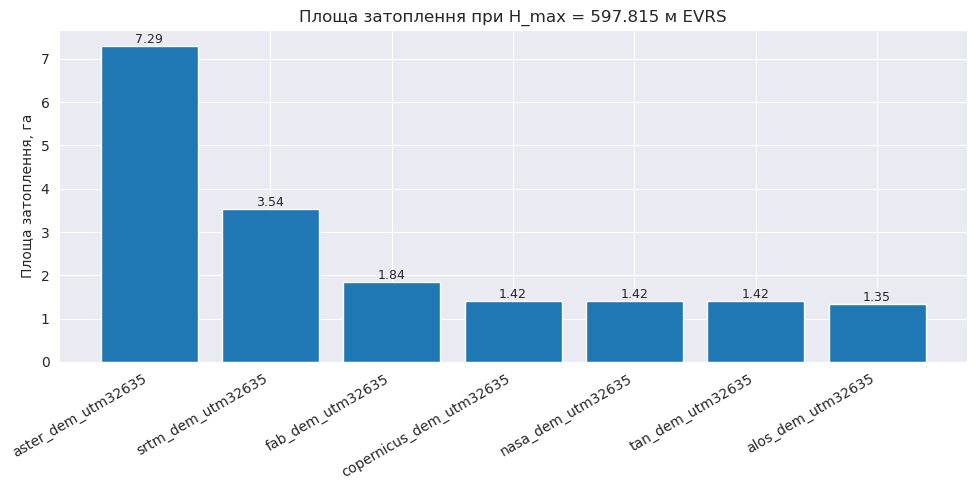

In [29]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CSV = r"/mnt/c/Users/5302/PycharmProjects/geoid/flood_area_out/flood_area_by_dem.csv"  # твій шлях

df = pd.read_csv(CSV)
df = df.sort_values("area_ha", ascending=False)
H = float(df["H_max_evrs_m"].iloc[0])

plt.figure(figsize=(10,5))
bars = plt.bar(df["dem"], df["area_ha"])
for b, val in zip(bars, df["area_ha"]):
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f"{val:.2f}",
             ha="center", va="bottom", fontsize=9)
plt.ylabel("Площа затоплення, га")
plt.title(f"Площа затоплення при H_max = {H:.3f} м EVRS")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("flood_area_ha_by_dem.png", dpi=160)
plt.show()


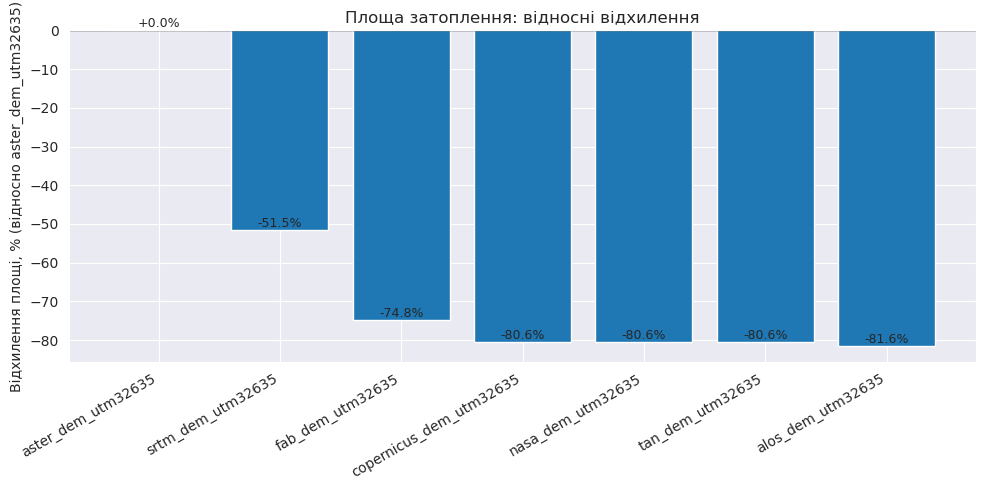

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

CSV = r"/mnt/c/Users/5302/PycharmProjects/geoid/flood_area_out/flood_area_by_dem.csv"
REF_NAME = "aster_dem_utm32635"   # зміни на свій еталон

df = pd.read_csv(CSV).set_index("dem")
if REF_NAME not in df.index:
    raise ValueError(f"Немає DEM '{REF_NAME}' у CSV")

ref = df.loc[REF_NAME, "area_ha"]
df["rel_vs_ref_%"] = 100.0 * (df["area_ha"]/ref - 1.0)

df_plot = df.sort_values("rel_vs_ref_%", ascending=False)

plt.figure(figsize=(10,5))
plt.axhline(0, lw=1, color="k")
bars = plt.bar(df_plot.index, df_plot["rel_vs_ref_%"])
for b, val in zip(bars, df_plot["rel_vs_ref_%"]):
    plt.text(b.get_x()+b.get_width()/2, b.get_height(),
             f"{val:+.1f}%", ha="center", va="bottom", fontsize=9)
plt.ylabel(f"Відхилення площі, % (відносно {REF_NAME})")
plt.title("Площа затоплення: відносні відхилення")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("flood_area_rel_percent.png", dpi=160)
plt.show()


In [33]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from pathlib import Path

# ================== INPUTS ==================
PROFILE_GEOJSON = r"/mnt/c/Users/5302/PycharmProjects/geoid/profile_combined_evrs.geojson"

DEM_DIR = Path(r"/mnt/d/paper_data/DEM_DATA/data/DATA_UTM/dem")
DEM_PATTERNS = {
    "alos_dem_utm32635":       "*alos*dem*32635*.tif",
    "aster_dem_utm32635":      "*aster*dem*32635*.tif",
    "copernicus_dem_utm32635": "*copernicus*dem*32635*.tif",
    "fab_dem_utm32635":        "*fab*dem*32635*.tif",
    "nasa_dem_utm32635":       "*nasa*dem*32635*.tif",
    "srtm_dem_utm32635":       "*srtm*dem*32635*.tif",
    "tan_dem_utm32635":        "*tan*dem*32635*.tif",
}

# Якщо знаєш зміщення конкретних DEM до EVRS (м) – пропиши тут
DEM_VERTICAL_OFFSETS = {
    # "aster_dem_utm32635": 0.0,
    # "copernicus_dem_utm32635": -0.40,
}

# Нуль поста (Балт-77) і перехід до EVRS
NULL_POSTA_BALT = 592.11
BALT_TO_EVRS    = 0.105

# Як задати рівень:
USE_H_FROM_GEOJSON = True     # True → беремо H_max_evrs_m з GeoJSON
LEVEL_CM = 168                # якщо USE_H_FROM_GEOJSON=False, використовуємо цей етап (см) від нуля поста

DX = 2.0                      # крок вертикалей, м

# ================== OUTPUTS ==================
OUT_DIR = Path(r"/mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out"); OUT_DIR.mkdir(exist_ok=True)
OUT_SUM  = OUT_DIR / "cross_dem_metrics.csv"
OUT_VERT = OUT_DIR / "cross_dem_verticals_2m.csv"

# ================== HELPERS ==================
import glob, unicodedata, math

def _normalize(s: str) -> str:
    return unicodedata.normalize("NFKC", s).lower()

def discover_dems(base_dir: Path, patterns: dict) -> dict:
    all_tifs = [Path(p) for p in glob.glob(str(base_dir/"*.tif"))]
    res = {}
    for label, pat in patterns.items():
        cand = [Path(p) for p in glob.glob(str(base_dir/pat))]
        if not cand:
            want = _normalize(label).split("_")
            for p in all_tifs:
                if all(tok in _normalize(p.name) for tok in want):
                    cand.append(p)
        if cand:
            res[label] = str(cand[0])
    return res

def interp_unique(x, y, xg):
    # np.interp вимагає зростаюче x без дублів
    x = np.asarray(x, float); y = np.asarray(y, float)
    order = np.argsort(x)
    x = x[order]; y = y[order]
    m = np.concatenate(([True], np.diff(x) > 1e-9))
    return np.interp(xg, x[m], y[m])

def sample_raster_lonlat(path, lon, lat):
    with rasterio.open(path) as src:
        pts = gpd.GeoSeries(gpd.points_from_xy(lon, lat), crs=4326).to_crs(src.crs)
        xs, ys = pts.x.to_numpy(), pts.y.to_numpy()
        vals = list(src.sample(zip(xs, ys)))
        arr = np.array([v[0] if len(v)>0 else np.nan for v in vals], float)
        if src.nodata is not None:
            arr = np.where(np.isclose(arr, src.nodata), np.nan, arr)
        return arr

def wetted_metrics(xg, zg, H):
    """A (м²), P (м), W (м), Dmean (м), R (м). Ураховує часткові перетини з рівнем."""
    xg = np.asarray(xg, float); zg = np.asarray(zg, float)
    d = np.maximum(H - zg, 0.0)
    dx = np.diff(xg)
    # Площа трапеціями
    A = np.sum((d[:-1] + d[1:]) * 0.5 * dx)
    # Ширина плеса (часткові перетини врахуємо як наявність води)
    W = np.sum(dx * ((d[:-1] > 0) | (d[1:] > 0)))
    # Змочений периметр
    P = 0.0
    for i in range(len(dx)):
        z0, z1 = zg[i], zg[i+1]
        below0 = z0 < H; below1 = z1 < H
        if below0 and below1:
            P += math.hypot(dx[i], z1 - z0)
        elif below0 != below1:
            t = (H - z0) / (z1 - z0)
            t = float(np.clip(t, 0.0, 1.0))
            if below0:
                dz_sub = (z0 + t*(z1 - z0)) - z0
                P += math.hypot(dx[i]*t, dz_sub)
            else:
                dz_sub = z1 - (z0 + t*(z1 - z0))
                P += math.hypot(dx[i]*(1-t), dz_sub)
    Dmean = A / W if W > 0 else 0.0
    R = A / P if P > 0 else 0.0
    return A, P, W, Dmean, R, d

# ================== MAIN ==================
# 1) Читаємо профільні точки
g = gpd.read_file(PROFILE_GEOJSON)
pts = g[g.get("kind").fillna("profile_point") == "profile_point"].copy()
pts = pts.sort_values("distance_m").reset_index(drop=True)

x = pts["distance_m"].to_numpy(float)
lon = pts.geometry.x.to_numpy(float)
lat = pts.geometry.y.to_numpy(float)

# Висоти профілю в EVRS (еталон)
if "elevation_evrs_m" in pts.columns:
    z_prof = pts["elevation_evrs_m"].to_numpy(float)
elif "elevation_m" in pts.columns:
    z_prof = pts["elevation_m"].to_numpy(float) + BALT_TO_EVRS
else:
    raise ValueError("Немає elevation_evrs_m / elevation_m у профілі.")

# Визначаємо рівень
if USE_H_FROM_GEOJSON and "H_max_evrs_m" in pts.columns:
    H = float(pts["H_max_evrs_m"].iloc[0])
else:
    H = (NULL_POSTA_BALT + BALT_TO_EVRS) + LEVEL_CM/100.0
print(f"[INFO] Рівень H = {H:.3f} м (EVRS)")

# 2) Рівномірні вертикалі кожні DX метрів
xg = np.arange(x.min(), x.max() + DX, DX)

# координати вертикалей (для семплінгу DEM по тих самих лон/лат)
lon_g = interp_unique(x, lon, xg)
lat_g = interp_unique(x, lat, xg)

# еталонний профіль на тій самій сітці
z_prof_g = interp_unique(x, z_prof, xg)

# 3) Рахуємо метрики для еталона
A0, P0, W0, D0, R0, d_prof = wetted_metrics(xg, z_prof_g, H)

rows = [{
    "source": "profile_evrs",
    "A_m2": A0, "P_m": P0, "W_m": W0, "D_mean_m": D0, "R_m": R0,
    "dA_vs_profile_m2": 0.0, "dP_vs_profile_m": 0.0,
    "rel_dA_%": 0.0, "rel_dP_%": 0.0
}]
vert_rows = []
for xi, zi, di in zip(xg, z_prof_g, d_prof):
    vert_rows.append({"source":"profile_evrs", "x_m":xi, "bed_elev_evrs_m":zi, "depth_m":di})

# 4) DEM-и: семплимо на тих самих вертикалях і рахуємо метрики
dem_paths = discover_dems(DEM_DIR, DEM_PATTERNS)
for name, path in dem_paths.items():
    z_dem = sample_raster_lonlat(path, lon_g, lat_g)
    # + можливий вертикальний зсув до EVRS
    z_dem = z_dem + float(DEM_VERTICAL_OFFSETS.get(name, 0.0))
    # інтерполяція NaN, якщо будуть
    if np.any(~np.isfinite(z_dem)):
        z_dem = pd.Series(z_dem).interpolate(limit_direction="both").to_numpy()
    A, P, W, Dm, R, d = wetted_metrics(xg, z_dem, H)
    rows.append({
        "source": name,
        "A_m2": A, "P_m": P, "W_m": W, "D_mean_m": Dm, "R_m": R,
        "dA_vs_profile_m2": A - A0,
        "dP_vs_profile_m":  P - P0,
        "rel_dA_%": (A - A0)/A0*100.0 if A0>0 else np.nan,
        "rel_dP_%": (P - P0)/P0*100.0 if P0>0 else np.nan
    })
    for xi, zi, di in zip(xg, z_dem, d):
        vert_rows.append({"source":name, "x_m":xi, "bed_elev_evrs_m":zi, "depth_m":di})

# 5) Збереження
pd.DataFrame(rows).sort_values("source").to_csv(OUT_SUM, index=False)
pd.DataFrame(vert_rows).to_csv(OUT_VERT, index=False)

print("[OK] saved:")
print("  metrics ->", OUT_SUM.resolve())
print("  verticals ->", OUT_VERT.resolve())


[INFO] Рівень H = 597.815 м (EVRS)
[OK] saved:
  metrics -> /mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out/cross_dem_metrics.csv
  verticals -> /mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out/cross_dem_verticals_2m.csv


[INFO] H = 597.815 m EVRS
[OK] metrics  -> /mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out/cross_dem_metrics.csv
[OK] verticals-> /mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out/cross_dem_verticals_2m.csv
[OK] lines   -> /mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out/plot_lines
[OK] polygons-> /mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out/plot_polygons
[OK] shores  -> /mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out/shorelines.csv
[OK] plot    -> /mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out/section_overlay.png


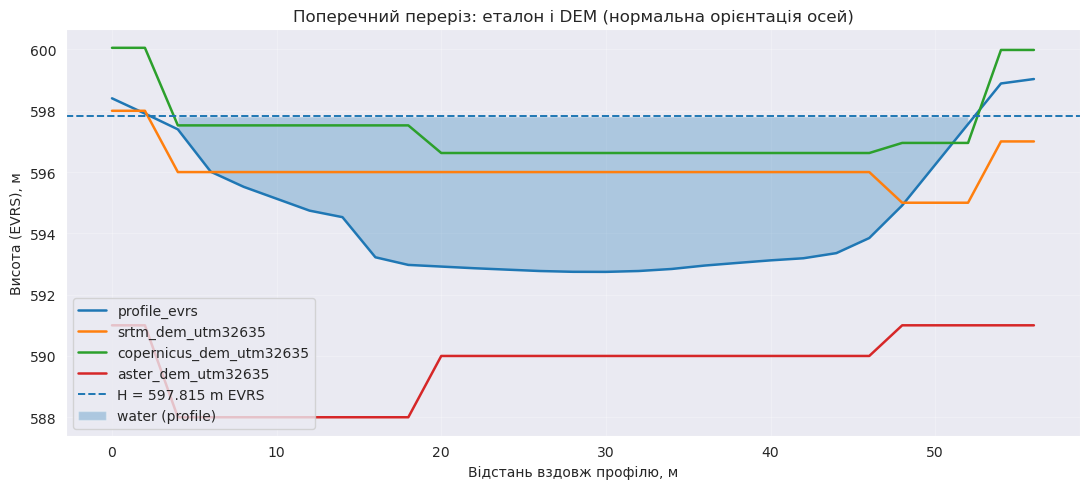

In [37]:
# -*- coding: utf-8 -*-
"""
ALL-IN-ONE:
- читає профіль (EVRS),
- визначає рівень H,
- семплить DEM уздовж профілю (ті самі вертикалі),
- рахує A, P, W, Dmean, R,
- пише metrics.csv, verticals.csv,
- готує координати для графіків: bed_line_xy.csv, wetted_polygon_xy.csv, shorelines.csv,
- робить один оглядовий PNG.

Вимоги: numpy, pandas, geopandas, rasterio, matplotlib
"""
import os, glob, unicodedata, math
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

# ================== INPUTS ==================
PROFILE_GEOJSON = r"/mnt/c/Users/5302/PycharmProjects/geoid/profile_combined_evrs.geojson"

DEM_DIR = Path(r"/mnt/d/paper_data/DEM_DATA/data/DATA_UTM/dem")
DEM_PATTERNS = {
    "alos_dem_utm32635":       "*alos*dem*32635*.tif",
    "aster_dem_utm32635":      "*aster*dem*32635*.tif",
    "copernicus_dem_utm32635": "*copernicus*dem*32635*.tif",
    "fab_dem_utm32635":        "*fab*dem*32635*.tif",
    "nasa_dem_utm32635":       "*nasa*dem*32635*.tif",
    "srtm_dem_utm32635":       "*srtm*dem*32635*.tif",
    "tan_dem_utm32635":        "*tan*dem*32635*.tif",
}
# систематичні вертикальні зсуви DEM до EVRS, м (якщо відомі)
DEM_VERTICAL_OFFSETS = {
    # "copernicus_dem_utm32635": -0.40,
}

# Нуль поста й перехід до EVRS (якщо не беремо H з GeoJSON)
NULL_POSTA_BALT = 592.11
BALT_TO_EVRS    = 0.105
USE_H_FROM_GEOJSON = True            # True → беремо H_max_evrs_m з GeoJSON
LEVEL_CM = 168                        # коли USE_H_FROM_GEOJSON=False

DX = 2.0                              # крок вертикалей, м
MAKE_PLOT = True                      # зробити оглядовий PNG
SOURCES_TO_PLOT = ["profile_evrs","srtm_dem_utm32635","copernicus_dem_utm32635","aster_dem_utm32635"]

# ================== OUTPUTS ==================
OUT_DIR   = Path(r"/mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_SUM   = OUT_DIR / "cross_dem_metrics.csv"
OUT_VERT  = OUT_DIR / "cross_dem_verticals_2m.csv"
LINES_DIR = OUT_DIR / "plot_lines";    LINES_DIR.mkdir(exist_ok=True)
POLYS_DIR = OUT_DIR / "plot_polygons"; POLYS_DIR.mkdir(exist_ok=True)
SHORE_CSV = OUT_DIR / "shorelines.csv"
PLOT_PNG  = OUT_DIR / "section_overlay.png"

# ================== HELPERS ==================
def _normalize(s: str) -> str:
    return unicodedata.normalize("NFKC", s).lower()

def discover_dems(base_dir: Path, patterns: dict) -> dict:
    all_tifs = [Path(p) for p in glob.glob(str(base_dir/"*.tif"))]
    res = {}
    for label, pat in patterns.items():
        cand = [Path(p) for p in glob.glob(str(base_dir/pat))]
        if not cand:
            want = _normalize(label).split("_")
            for p in all_tifs:
                if all(tok in _normalize(p.name) for tok in want):
                    cand.append(p)
        if cand:
            res[label] = str(cand[0])
    return res

def interp_unique(x, y, xg):
    x = np.asarray(x, float); y = np.asarray(y, float)
    o = np.argsort(x); x = x[o]; y = y[o]
    m = np.concatenate(([True], np.diff(x) > 1e-9))
    return np.interp(xg, x[m], y[m])

def sample_raster_lonlat(path, lon, lat):
    with rasterio.open(path) as src:
        pts = gpd.GeoSeries(gpd.points_from_xy(lon, lat), crs=4326).to_crs(src.crs)
        xs, ys = pts.x.to_numpy(), pts.y.to_numpy()
        vals = list(src.sample(zip(xs, ys)))
        arr = np.array([v[0] if len(v)>0 else np.nan for v in vals], float)
        if src.nodata is not None:
            arr = np.where(np.isclose(arr, src.nodata), np.nan, arr)
        return arr

def wetted_metrics(xg, zg, H):
    """Повертає (A,P,W,Dmean,R) та вектор глибин d для розрізу."""
    xg = np.asarray(xg, float); zg = np.asarray(zg, float)
    d = np.maximum(H - zg, 0.0)
    dx = np.diff(xg)
    A = np.sum((d[:-1] + d[1:]) * 0.5 * dx)
    W = np.sum(dx * ((d[:-1] > 0) | (d[1:] > 0)))
    P = 0.0
    for i in range(len(dx)):
        z0, z1 = zg[i], zg[i+1]
        below0 = z0 < H; below1 = z1 < H
        if below0 and below1:
            P += math.hypot(dx[i], z1 - z0)
        elif below0 != below1:
            t = (H - z0) / (z1 - z0)
            t = float(np.clip(t, 0.0, 1.0))
            if below0:
                dz = (z0 + t*(z1 - z0)) - z0
                P += math.hypot(dx[i]*t, dz)
            else:
                dz = z1 - (z0 + t*(z1 - z0))
                P += math.hypot(dx[i]*(1-t), dz)
    Dmean = A / W if W > 0 else 0.0
    R = A / P if P > 0 else 0.0
    return A, P, W, Dmean, R, d

def wetted_polygon_xy(x, z, H):
    """Замкнений полігон змоченої частини перерізу (для філлу на графіку)."""
    x = np.asarray(x, float); z = np.asarray(z, float); n = len(x)
    if n < 2: return np.empty((0,2)), (np.nan, np.nan)
    below = z < H
    if not below.any(): return np.empty((0,2)), (np.nan, np.nan)
    if below.all():
        xs = np.r_[x[0], x, x[-1], x[0]]
        zs = np.r_[H,    z, H,     H]
        return np.column_stack([xs, zs]), (x[0], x[-1])

    def edge_x(i0, i1):
        z0, z1 = z[i0], z[i1]
        t = float(np.clip((H - z0)/(z1 - z0), 0.0, 1.0))
        return x[i0] + t * (x[i1] - x[i0])

    # left edge
    if below[0]: xL = x[0]
    else:
        i = next(i for i in range(n-1) if (z[i]-H)*(z[i+1]-H) < 0)
        xL = edge_x(i, i+1)
    # right edge
    if below[-1]: xR = x[-1]
    else:
        j = next(i for i in range(n-2, -1, -1) if (z[i]-H)*(z[i+1]-H) < 0)
        xR = edge_x(j, j+1)

    idx = np.where((x >= min(xL,xR)) & (x <= max(xL,xR)))[0]
    xs = list(x[idx]); zs = list(z[idx])
    if len(xs)==0 or xs[0] > xL + 1e-9: xs.insert(0, xL); zs.insert(0, H)
    if xs[-1] < xR - 1e-9:              xs.append(xR);  zs.append(H)
    poly_x = [xL] + xs + [xR, xL]
    poly_z = [H ] + zs + [H,  H ]
    return np.column_stack([poly_x, poly_z]), (xL, xR)

# ================== PIPELINE ==================
# 1) профіль
g = gpd.read_file(PROFILE_GEOJSON)
pts = g[g.get("kind").fillna("profile_point") == "profile_point"].copy()
pts = pts.sort_values("distance_m").reset_index(drop=True)
x   = pts["distance_m"].to_numpy(float)
lon = pts.geometry.x.to_numpy(float)
lat = pts.geometry.y.to_numpy(float)

# EVRS висота профілю
if "elevation_evrs_m" in pts.columns:
    z_prof = pts["elevation_evrs_m"].to_numpy(float)
elif "elevation_m" in pts.columns:
    z_prof = pts["elevation_m"].to_numpy(float) + BALT_TO_EVRS
else:
    raise ValueError("Немає elevation_evrs_m / elevation_m у профілі.")

# H
if USE_H_FROM_GEOJSON and "H_max_evrs_m" in pts.columns:
    H = float(pts["H_max_evrs_m"].iloc[0])
else:
    H = (NULL_POSTA_BALT + BALT_TO_EVRS) + LEVEL_CM/100.0
print(f"[INFO] H = {H:.3f} m EVRS")

# 2) вертикалі через DX
xg    = np.arange(x.min(), x.max()+DX, DX)
lon_g = interp_unique(x, lon, xg)
lat_g = interp_unique(x, lat, xg)
zpg   = interp_unique(x, z_prof, xg)

# 3) еталонні метрики
A0, P0, W0, D0, R0, d_prof = wetted_metrics(xg, zpg, H)
rows = [{
    "source":"profile_evrs","A_m2":A0,"P_m":P0,"W_m":W0,"D_mean_m":D0,"R_m":R0,
    "dA_vs_profile_m2":0.0,"dP_vs_profile_m":0.0,"rel_dA_%":0.0,"rel_dP_%":0.0
}]
verts_rec = [{"source":"profile_evrs","x_m":xi,"bed_elev_evrs_m":zi,"depth_m":di}
             for xi,zi,di in zip(xg,zpg,d_prof)]

# 4) DEM-и
dem_paths = discover_dems(DEM_DIR, DEM_PATTERNS)
for name, path in dem_paths.items():
    z_dem = sample_raster_lonlat(path, lon_g, lat_g)
    z_dem = z_dem + float(DEM_VERTICAL_OFFSETS.get(name, 0.0))
    if np.any(~np.isfinite(z_dem)):
        z_dem = pd.Series(z_dem).interpolate(limit_direction="both").to_numpy()
    A,P,W,Dm,R,d = wetted_metrics(xg, z_dem, H)
    rows.append({
        "source":name,"A_m2":A,"P_m":P,"W_m":W,"D_mean_m":Dm,"R_m":R,
        "dA_vs_profile_m2":A-A0,"dP_vs_profile_m":P-P0,
        "rel_dA_%":(A-A0)/A0*100.0 if A0>0 else np.nan,
        "rel_dP_%":(P-P0)/P0*100.0 if P0>0 else np.nan
    })
    verts_rec += [{"source":name,"x_m":xi,"bed_elev_evrs_m":zi,"depth_m":di}
                  for xi,zi,di in zip(xg,z_dem,d)]

# 5) збереження таблиць
df_sum  = pd.DataFrame(rows).sort_values("source")
df_vert = pd.DataFrame(verts_rec)
df_sum.to_csv(OUT_SUM, index=False)
df_vert.to_csv(OUT_VERT, index=False)
print("[OK] metrics  ->", OUT_SUM)
print("[OK] verticals->", OUT_VERT)

# 6) координати для графіків + береги
shore_rows = []
for src, d in df_vert.groupby("source"):
    d = d.sort_values("x_m")
    x = d["x_m"].to_numpy(float)
    z = d["bed_elev_evrs_m"].to_numpy(float)

    # лінія дна
    pd.DataFrame({"x_m":x, "z_evrs_m":z}).to_csv(LINES_DIR/f"{src}_bed_line_xy.csv", index=False)

    # полігон змоченого перерізу
    poly, (xL, xR) = wetted_polygon_xy(x, z, H)
    if poly.size > 0:
        pd.DataFrame({"x_m":poly[:,0], "z_evrs_m":poly[:,1]}) \
            .to_csv(POLYS_DIR/f"{src}_wetted_polygon_xy.csv", index=False)
    shore_rows.append({"source":src, "x_left_m":xL, "x_right_m":xR, "width_W_m":(xR-xL)})

pd.DataFrame(shore_rows).to_csv(SHORE_CSV, index=False)
print("[OK] lines   ->", LINES_DIR)
print("[OK] polygons->", POLYS_DIR)
print("[OK] shores  ->", SHORE_CSV)
INVERT_Y = False  # <-- тепер за замовчуванням НЕ інвертуємо вісь

# 7) оглядовий графік (вісь H вгору)
if MAKE_PLOT:
    plt.figure(figsize=(11,5))

    # лінії дна для вибраних джерел
    for src in SOURCES_TO_PLOT:
        d = df_vert[df_vert["source"]==src].sort_values("x_m")
        if d.empty:
            continue
        plt.plot(d["x_m"], d["bed_elev_evrs_m"], label=src, linewidth=1.8)

    # горизонтальна водолінія
    plt.axhline(H, ls="--", lw=1.4, label=f"H = {H:.3f} m EVRS")

    # акуратно залити «воду» для еталона (тільки там, де дно нижче H)
    d0 = df_vert[df_vert["source"]=="profile_evrs"].sort_values("x_m")
    x0 = d0["x_m"].to_numpy(float)
    z0 = d0["bed_elev_evrs_m"].to_numpy(float)
    plt.fill_between(x0, z0, H, where=(z0 < H), alpha=0.30, label="water (profile)")

    # БІЛЬШ НЕ ІНВЕРТУЄМО ОСЬ — усе «в людському» вигляді
    if INVERT_Y:
        plt.gca().invert_yaxis()

    plt.grid(alpha=0.25)
    plt.xlabel("Відстань вздовж профілю, м")
    plt.ylabel("Висота (EVRS), м")
    plt.title("Поперечний переріз: еталон і DEM (нормальна орієнтація осей)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_PNG, dpi=160)
    print("[OK] plot    ->", PLOT_PNG)



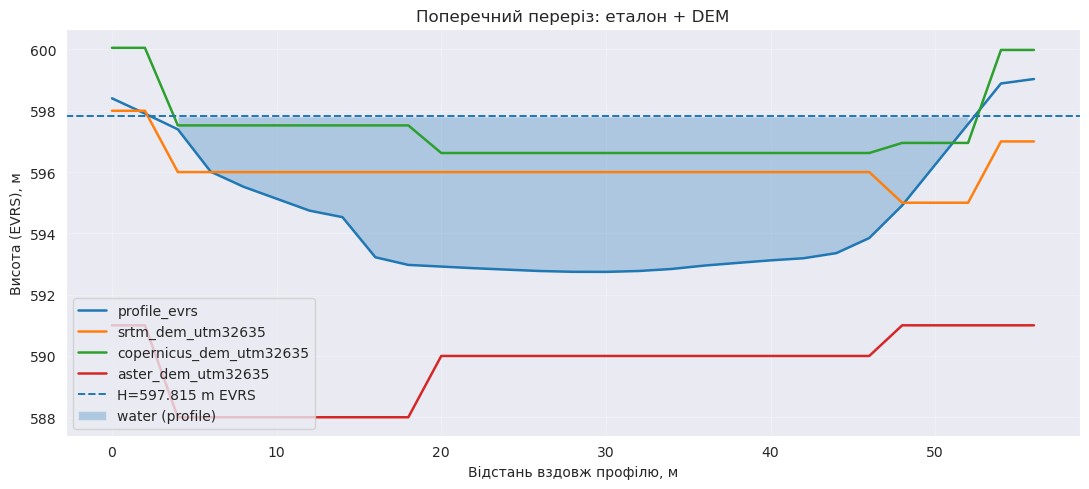

In [38]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
OUT_DIR = r"/mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out"
VERT = os.path.join(OUT_DIR, "cross_dem_verticals_2m.csv")
df = pd.read_csv(VERT)

# рівень води беремо з еталонних вертикалей (median(bed+depth) по підводних точках)
d0 = df[df.source=="profile_evrs"].sort_values("x_m")
H  = float(np.nanmedian(d0.bed_elev_evrs_m + d0.depth_m))

sources = ["profile_evrs","srtm_dem_utm32635","copernicus_dem_utm32635","aster_dem_utm32635"]
plt.figure(figsize=(11,5))
for s in sources:
    d = df[df.source==s].sort_values("x_m")
    if d.empty: continue
    plt.plot(d.x_m, d.bed_elev_evrs_m, label=s, lw=1.8)

# водолінія та заливка лише там, де дно нижче H
plt.axhline(H, ls="--", lw=1.4, label=f"H={H:.3f} m EVRS")
z = d0.bed_elev_evrs_m.to_numpy(float)
x = d0.x_m.to_numpy(float)
plt.fill_between(x, z, H, where=(z < H), alpha=0.3, label="water (profile)")

plt.grid(alpha=0.25)
plt.xlabel("Відстань вздовж профілю, м")
plt.ylabel("Висота (EVRS), м")
plt.title("Поперечний переріз: еталон + DEM")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "section_overlay_up.png"), dpi=160)
plt.show()


In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from pathlib import Path


In [3]:
# ----- HAND inputs -----
HAND_DIR = Path(r"/mnt/d/paper_data/DEM_DATA/data/DATA_UTM/dem/HAND")  # твоя папка HAND
# таргет-діапазон HAND: [h0 - tol, h0 + tol] (мінімум 0)
HAND_H0  = 5.6    # м над руслом (цільовий рівень)
HAND_TOL = 5.0    # ± толеранс, м
SAVE_HAND_MASKS = False  # True → зберігати маски-геотіфи по всіх растрах


In [5]:
def discover_hands(hand_dir: Path, dem_map: dict) -> dict:
    """
    Шукаємо HAND-растр для кожного DEM-лейбла:
    1) пробуємо файли типу "*<label>*hand*.tif"
    2) якщо не знайшли — шукаємо за токенами label + 'hand'
    """
    all_tifs = [Path(p) for p in glob.glob(str(hand_dir/"*.tif"))]
    res = {}
    for label in dem_map.keys():
        # найчастіші імена: <label>_hand.tif або ...hand...
        pats = [
            f"*{label}*hand*.tif",
            f"*{label.replace('dem','dem*hand')}*.tif",
        ]
        cand = []
        for pat in pats:
            cand = [Path(p) for p in glob.glob(str(hand_dir/pat))]
            if cand: break
        if not cand:
            # фолбек: токени label + 'hand'
            want = _normalize(label).split("_") + ["hand"]
            for p in all_tifs:
                if all(tok in _normalize(p.name) for tok in want):
                    cand.append(p)
                    break
        if cand:
            res[label] = str(cand[0])
    return res


def count_band_pixels(hand_path: str, lo: float, hi: float):
    """
    Повертає (n_pixels, pixel_area_m2, total_area_m2) для HAND ∈ [lo,hi].
    Якщо CRS у градусах — pixel_area_m2 буде None.
    """
    with rasterio.open(hand_path) as src:
        arr = src.read(1, masked=True)
        valid = ~arr.mask
        in_band = valid & (arr >= lo) & (arr <= hi)
        n = int(in_band.sum())

        # оцінка площі пікселя — тільки для метричних CRS
        try:
            # у більшості UTM transform.e < 0 → беремо модуль
            pix_w = abs(src.transform.a)
            pix_h = abs(src.transform.e)
            px_area = float(pix_w * pix_h)
        except Exception:
            px_area = None

        tot_area = (n * px_area) if (px_area is not None) else None

        return n, px_area, tot_area


def sample_hand_along_profile(hand_path: str, lon_g, lat_g):
    """HAND значення уздовж профілю (координати lon/lat → CRS растру всередині)."""
    return sample_raster_lonlat(hand_path, lon_g, lat_g)


[INFO] H = 597.815 m EVRS
[INFO] Found DEMs: ['alos_dem_utm32635', 'aster_dem_utm32635', 'copernicus_dem_utm32635', 'fab_dem_utm32635', 'nasa_dem_utm32635', 'srtm_dem_utm32635', 'tan_dem_utm32635']
[OK] metrics   -> /mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out/cross_dem_metrics.csv
[OK] verticals -> /mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out/cross_dem_verticals_2m.csv
[OK] lines     -> /mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out/plot_lines
[OK] polygons  -> /mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out/plot_polygons
[OK] shores    -> /mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out/shorelines.csv
[OK] plot     -> /mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out/section_overlay.png
[INFO] Found HANDs: ['alos_dem_utm32635', 'aster_dem_utm32635', 'fab_dem_utm32635', 'nasa_dem_utm32635', 'srtm_dem_utm32635', 'tan_dem_utm32635']
[HAND] band: HAND ∈ [0.60, 10.60] m  (h0=5.6, tol=±5.0)
[OK] HAND profile -> /mnt/c/Users/5302/PycharmProjects/geoid

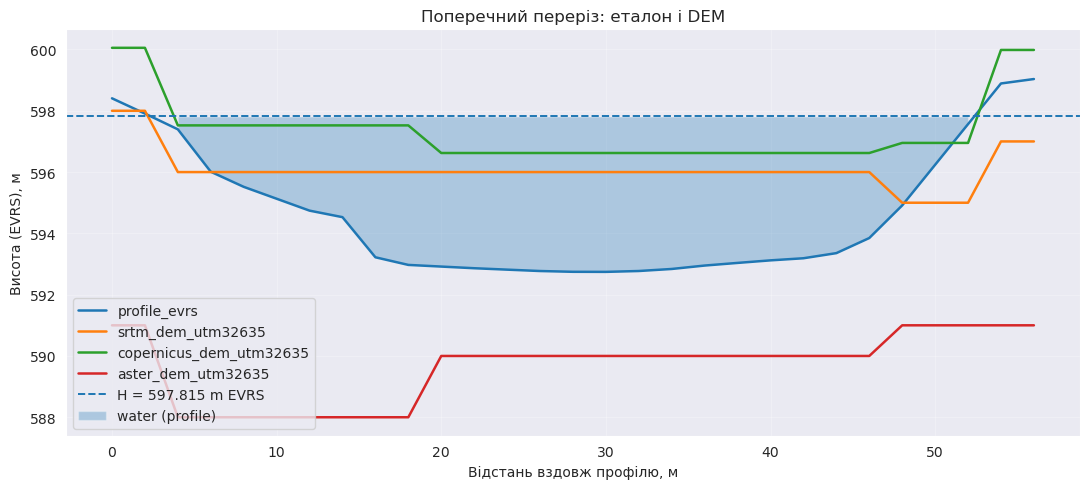

In [6]:
# -*- coding: utf-8 -*-
"""
ALL-IN-ONE (DEM + HAND):
- читає профіль (EVRS),
- визначає рівень H,
- семплить DEM уздовж профілю (вертикалі через DX),
- рахує A, P, W, Dmean, R і похибки відносно профілю,
- пише:
    cross_dem_metrics.csv
    cross_dem_verticals_2m.csv
    bed_line_xy/*.csv
    wetted_polygon_xy/*.csv
    shorelines.csv
- генерує оглядовий PNG (без інверсії осі Y)
- + HAND:
    hand_on_profile.csv
    hand_band_summary.csv
    (опц.) hand_masks/*.tif

Вимоги: numpy, pandas, geopandas, rasterio, matplotlib
"""

import os, glob, unicodedata, math, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

# ================== INPUTS ==================
# Профіль (GeoJSON з точками лінії поперечного перерізу)
PROFILE_GEOJSON = r"/mnt/c/Users/5302/PycharmProjects/geoid/profile_combined_evrs.geojson"

# DEM
DEM_DIR = Path(r"/mnt/d/paper_data/DEM_DATA/data/DATA_UTM/dem")
DEM_PATTERNS = {
    "alos_dem_utm32635":       "*alos*dem*32635*.tif",
    "aster_dem_utm32635":      "*aster*dem*32635*.tif",
    "copernicus_dem_utm32635": "*copernicus*dem*32635*.tif",
    "fab_dem_utm32635":        "*fab*dem*32635*.tif",
    "nasa_dem_utm32635":       "*nasa*dem*32635*.tif",
    "srtm_dem_utm32635":       "*srtm*dem*32635*.tif",
    "tan_dem_utm32635":        "*tan*dem*32635*.tif",
}
# систематичні вертикальні зсуви DEM до EVRS, м (за потреби)
DEM_VERTICAL_OFFSETS = {
    # "copernicus_dem_utm32635": -0.40,
}

# HAND
HAND_DIR = Path(r"/mnt/d/paper_data/DEM_DATA/data/DATA_UTM/dem/HAND")
HAND_H0  = 5.6   # цільова висота над руслом (м)
HAND_TOL = 5.0   # ± допуск (м) → діапазон [h0 - tol, h0 + tol]
SAVE_HAND_MASKS = False  # True → зберігати маски-GeoTIFF

# Нуль поста і перехід до EVRS (коли не беремо H з GeoJSON)
NULL_POSTA_BALT = 592.11
BALT_TO_EVRS    = 0.105
USE_H_FROM_GEOJSON = True           # True → беремо H_max_evrs_m з GeoJSON (якщо є)
LEVEL_CM = 168                      # fallback рівень у см над нулем поста (якщо USE_H_FROM_GEOJSON=False)

# семплінг уздовж профілю
DX = 2.0

# графіка
MAKE_PLOT = True
SOURCES_TO_PLOT = ["profile_evrs","srtm_dem_utm32635","copernicus_dem_utm32635","aster_dem_utm32635"]

# ================== OUTPUTS ==================
OUT_DIR   = Path(r"/mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_SUM   = OUT_DIR / "cross_dem_metrics.csv"
OUT_VERT  = OUT_DIR / "cross_dem_verticals_2m.csv"
LINES_DIR = OUT_DIR / "plot_lines";    LINES_DIR.mkdir(exist_ok=True)
POLYS_DIR = OUT_DIR / "plot_polygons"; POLYS_DIR.mkdir(exist_ok=True)
SHORE_CSV = OUT_DIR / "shorelines.csv"
PLOT_PNG  = OUT_DIR / "section_overlay.png"

OUT_HAND_PROF = OUT_DIR / "hand_on_profile.csv"
OUT_HAND_SUM  = OUT_DIR / "hand_band_summary.csv"
HAND_MASK_DIR = OUT_DIR / "hand_masks"
OUT_HAND_EVRS = OUT_DIR / "hand_evrs_profile.csv"


# ================== HELPERS ==================
def _normalize(s: str) -> str:
    return unicodedata.normalize("NFKC", s).lower()

def discover_files(base_dir: Path, patterns: dict) -> dict:
    """Повертає {label: path} для перших знайдених GeoTIFF за шаблонами."""
    all_tifs = [Path(p) for p in glob.glob(str(base_dir/"*.tif"))]
    res = {}
    for label, pat in patterns.items():
        cand = [Path(p) for p in glob.glob(str(base_dir/pat))]
        if not cand:
            want = _normalize(label).split("_")
            for p in all_tifs:
                if all(tok in _normalize(p.name) for tok in want):
                    cand.append(p)
                    break
        if cand:
            res[label] = str(cand[0])
    return res

def discover_hands(hand_dir: Path, dem_map: dict) -> dict:
    """Підбираємо HAND для кожного DEM-лейбла."""
    all_tifs = [Path(p) for p in glob.glob(str(hand_dir/"*.tif"))]
    res = {}
    for label in dem_map.keys():
        pats = [f"*{label}*hand*.tif", f"*{label.replace('dem','dem*hand')}*.tif"]
        cand = []
        for pat in pats:
            cand = [Path(p) for p in glob.glob(str(hand_dir/pat))]
            if cand: break
        if not cand:
            want = _normalize(label).split("_") + ["hand"]
            for p in all_tifs:
                if all(tok in _normalize(p.name) for tok in want):
                    cand.append(p); break
        if cand:
            res[label] = str(cand[0])
    return res

def interp_unique(x, y, xg):
    """Монотонізує x, прибирає дублікати, інтерполює y(x) → y(xg)."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    o = np.argsort(x); x = x[o]; y = y[o]
    m = np.concatenate(([True], np.diff(x) > 1e-9))
    return np.interp(xg, x[m], y[m])

def sample_raster_lonlat(path, lon, lat):
    """Семплінг растра у довільних lon/lat через reprojection до CRS растру."""
    with rasterio.open(path) as src:
        pts = gpd.GeoSeries(gpd.points_from_xy(lon, lat), crs=4326).to_crs(src.crs)
        xs, ys = pts.x.to_numpy(), pts.y.to_numpy()
        vals = list(src.sample(zip(xs, ys)))
        arr = np.array([v[0] if len(v)>0 else np.nan for v in vals], float)
        if src.nodata is not None:
            arr = np.where(np.isclose(arr, src.nodata), np.nan, arr)
        return arr

def safe_naninterp(arr: np.ndarray) -> np.ndarray:
    """Заповнення NaN лінійною інтерполяцією (в обидва боки)."""
    s = pd.Series(arr, dtype="float64")
    return s.interpolate(limit_direction="both").to_numpy()

def wetted_metrics(xg, zg, H):
    """
    A, P, W, Dmean, R + вектор глибин уздовж перерізу.
    - A: площа змоченого перерізу
    - P: змочений периметр
    - W: ширина дзеркала (top width)
    - Dmean: середня глибина A/W
    - R: гідравл. радіус A/P
    """
    xg = np.asarray(xg, float); zg = np.asarray(zg, float)
    d = np.maximum(H - zg, 0.0)
    dx = np.diff(xg)

    # Площа трапеціями (тільки там, де d>0)
    A = np.sum((d[:-1] + d[1:]) * 0.5 * dx)

    # Ширина дзеркала: будь-яка пара сегментів з водою дає внесок dx
    W = np.sum(dx * ((d[:-1] > 0) | (d[1:] > 0)))

    # Змочений периметр уздовж дна (з урахуванням зрізів на H)
    P = 0.0
    for i in range(len(dx)):
        z0, z1 = zg[i], zg[i+1]
        below0 = z0 < H; below1 = z1 < H
        if below0 and below1:
            P += math.hypot(dx[i], z1 - z0)
        elif below0 != below1:
            # перетин з H
            t = (H - z0) / (z1 - z0)
            t = float(np.clip(t, 0.0, 1.0))
            if below0:
                dz = (z0 + t*(z1 - z0)) - z0
                P += math.hypot(dx[i]*t, dz)
            else:
                dz = z1 - (z0 + t*(z1 - z0))
                P += math.hypot(dx[i]*(1-t), dz)

    Dmean = A / W if W > 0 else 0.0
    R = A / P if P > 0 else 0.0
    return A, P, W, Dmean, R, d

def wetted_polygon_xy(x, z, H):
    """Повертає полігон змоченої частини (x,z) та (xL,xR) берегові межі."""
    x = np.asarray(x, float); z = np.asarray(z, float); n = len(x)
    if n < 2: return np.empty((0,2)), (np.nan, np.nan)
    below = z < H
    if not below.any(): return np.empty((0,2)), (np.nan, np.nan)
    if below.all():
        xs = np.r_[x[0], x, x[-1], x[0]]
        zs = np.r_[H,    z, H,     H]
        return np.column_stack([xs, zs]), (x[0], x[-1])

    def edge_x(i0, i1):
        z0, z1 = z[i0], z[i1]
        t = float(np.clip((H - z0)/(z1 - z0), 0.0, 1.0))
        return x[i0] + t * (x[i1] - x[i0])

    # left edge
    if below[0]: xL = x[0]
    else:
        i = next(i for i in range(n-1) if (z[i]-H)*(z[i+1]-H) < 0)
        xL = edge_x(i, i+1)
    # right edge
    if below[-1]: xR = x[-1]
    else:
        j = next(i for i in range(n-2, -1, -1) if (z[i]-H)*(z[i+1]-H) < 0)
        xR = edge_x(j, j+1)

    idx = np.where((x >= min(xL,xR)) & (x <= max(xL,xR)))[0]
    xs = list(x[idx]); zs = list(z[idx])
    if len(xs)==0 or xs[0] > xL + 1e-9: xs.insert(0, xL); zs.insert(0, H)
    if xs[-1] < xR - 1e-9:              xs.append(xR);  zs.append(H)
    poly_x = [xL] + xs + [xR, xL]
    poly_z = [H ] + zs + [H,  H ]
    return np.column_stack([poly_x, poly_z]), (xL, xR)

def count_band_pixels(hand_path: str, lo: float, hi: float):
    """
    Повертає (n_pixels, pixel_area_m2, total_area_m2) для HAND ∈ [lo,hi].
    Площа пікселя рахується тільки для метричного CRS.
    """
    with rasterio.open(hand_path) as src:
        arr = src.read(1, masked=True)
        valid = ~arr.mask
        in_band = valid & (arr >= lo) & (arr <= hi)
        n = int(in_band.sum())

        # оцінка площі пікселя (для UTM |a|×|e|)
        try:
            pix_w = abs(src.transform.a)
            pix_h = abs(src.transform.e)
            px_area = float(pix_w * pix_h)
            # якщо CRS не метричний — ставимо NaN
            try:
                if not src.crs or not src.crs.is_projected:
                    px_area = np.nan
            except Exception:
                pass
        except Exception:
            px_area = np.nan

        tot_area = float(n * px_area) if np.isfinite(px_area) else np.nan
        return n, (px_area if np.isfinite(px_area) else np.nan), (tot_area if np.isfinite(tot_area) else np.nan)


    # 1) Профіль ---------------------------------------------------------
    g = gpd.read_file(PROFILE_GEOJSON)
    kind = g.get("kind").fillna("profile_point")
    pts = g[kind == "profile_point"].copy()
    if "distance_m" not in pts.columns:
        raise ValueError("У GeoJSON немає поля 'distance_m' для впорядкування профілю.")
    pts = pts.sort_values("distance_m").reset_index(drop=True)

    x   = pts["distance_m"].to_numpy(float)
    lon = pts.geometry.x.to_numpy(float)
    lat = pts.geometry.y.to_numpy(float)

    # EVRS висоти профілю
    if "elevation_evrs_m" in pts.columns:
        z_prof = pts["elevation_evrs_m"].to_numpy(float)
    elif "elevation_m" in pts.columns:
        z_prof = pts["elevation_m"].to_numpy(float) + BALT_TO_EVRS
    else:
        raise ValueError("Немає elevation_evrs_m / elevation_m у профілі.")

    # Рівень H
    if USE_H_FROM_GEOJSON and "H_max_evrs_m" in pts.columns and pts["H_max_evrs_m"].notna().any():
        H = float(pts["H_max_evrs_m"].dropna().iloc[0])
    else:
        H = (NULL_POSTA_BALT + BALT_TO_EVRS) + LEVEL_CM/100.0
    print(f"[INFO] H = {H:.3f} m EVRS")

    # 2) Вертикалі через DX ----------------------------------------------
    xg    = np.arange(x.min(), x.max() + DX, DX)
    lon_g = interp_unique(x, lon, xg)
    lat_g = interp_unique(x, lat, xg)
    zpg   = interp_unique(x, z_prof, xg)

    # 3) Еталонні метрики (профіль) --------------------------------------
    A0, P0, W0, D0, R0, d_prof = wetted_metrics(xg, zpg, H)
    rows = [{
        "source":"profile_evrs","A_m2":A0,"P_m":P0,"W_m":W0,"D_mean_m":D0,"R_m":R0,
        "dA_vs_profile_m2":0.0,"dP_vs_profile_m":0.0,"rel_dA_%":0.0,"rel_dP_%":0.0
    }]
    verts_rec = [{"source":"profile_evrs","x_m":xi,"bed_elev_evrs_m":zi,"depth_m":di}
                 for xi,zi,di in zip(xg,zpg,d_prof)]

    # 4) DEM-и ------------------------------------------------------------
    dem_paths = discover_files(DEM_DIR, DEM_PATTERNS)
    print(f"[INFO] Found DEMs: {list(dem_paths.keys())}")

    for name, path in dem_paths.items():
        z_dem = sample_raster_lonlat(path, lon_g, lat_g)
        if np.all(~np.isfinite(z_dem)):
            print(f"[WARN] All NaN for DEM: {name} — пропускаю.")
            continue
        z_dem = safe_naninterp(z_dem)  # заповнюємо NaN
        z_dem = z_dem + float(DEM_VERTICAL_OFFSETS.get(name, 0.0))

        A,P,W,Dm,R,d = wetted_metrics(xg, z_dem, H)
        rows.append({
            "source":name,"A_m2":A,"P_m":P,"W_m":W,"D_mean_m":Dm,"R_m":R,
            "dA_vs_profile_m2":A-A0,"dP_vs_profile_m":P-P0,
            "rel_dA_%": ((A-A0)/A0*100.0) if A0>0 else np.nan,
            "rel_dP_%": ((P-P0)/P0*100.0) if P0>0 else np.nan
        })
        verts_rec += [{"source":name,"x_m":xi,"bed_elev_evrs_m":zi,"depth_m":di}
                      for xi,zi,di in zip(xg,z_dem,d)]

    # 5) Збереження DEM-таблиць ------------------------------------------
    df_sum  = pd.DataFrame(rows).sort_values("source")
    df_vert = pd.DataFrame(verts_rec)
    df_sum.to_csv(OUT_SUM, index=False)
    df_vert.to_csv(OUT_VERT, index=False)
    print("[OK] metrics   ->", OUT_SUM)
    print("[OK] verticals ->", OUT_VERT)

    # 6) Координати для графіків + береги --------------------------------
    shore_rows = []
    for src, d in df_vert.groupby("source"):
        d = d.sort_values("x_m")
        xx = d["x_m"].to_numpy(float)
        zz = d["bed_elev_evrs_m"].to_numpy(float)

        # лінія дна
        pd.DataFrame({"x_m":xx, "z_evrs_m":zz}).to_csv(LINES_DIR/f"{src}_bed_line_xy.csv", index=False)

        # полігон змоченого перерізу
        poly, (xL, xR) = wetted_polygon_xy(xx, zz, H)
        if poly.size > 0:
            pd.DataFrame({"x_m":poly[:,0], "z_evrs_m":poly[:,1]}) \
                .to_csv(POLYS_DIR/f"{src}_wetted_polygon_xy.csv", index=False)
        shore_rows.append({"source":src, "x_left_m":xL, "x_right_m":xR, "width_W_m":(xR-xL)})

    pd.DataFrame(shore_rows).to_csv(SHORE_CSV, index=False)
    print("[OK] lines     ->", LINES_DIR)
    print("[OK] polygons  ->", POLYS_DIR)
    print("[OK] shores    ->", SHORE_CSV)

    # 7) Оглядовий графік -------------------------------------------------
    if MAKE_PLOT:
        plt.figure(figsize=(11,5))
        # Лінії дна
        for src in SOURCES_TO_PLOT:
            d = df_vert[df_vert["source"]==src].sort_values("x_m")
            if d.empty: continue
            plt.plot(d["x_m"], d["bed_elev_evrs_m"], label=src, linewidth=1.8)
        # рівень H
        plt.axhline(H, ls="--", lw=1.4, label=f"H = {H:.3f} m EVRS")
        # вода (профіль)
        d0 = df_vert[df_vert["source"]=="profile_evrs"].sort_values("x_m")
        if not d0.empty:
            x0 = d0["x_m"].to_numpy(float)
            z0 = d0["bed_elev_evrs_m"].to_numpy(float)
            plt.fill_between(x0, z0, H, where=(z0 < H), alpha=0.30, label="water (profile)")
        plt.grid(alpha=0.25)
        plt.xlabel("Відстань вздовж профілю, м")
        plt.ylabel("Висота (EVRS), м")
        plt.title("Поперечний переріз: еталон і DEM")
        plt.legend()
        plt.tight_layout()
        plt.savefig(PLOT_PNG, dpi=160)
        print("[OK] plot     ->", PLOT_PNG)

    # 8) HAND: діапазон [h0 ± tol] + профіль ------------------------------
    dem_paths = discover_files(DEM_DIR, DEM_PATTERNS)  # (на випадок, якщо вище фільтрували)
    hand_paths = discover_hands(HAND_DIR, dem_paths)
    print(f"[INFO] Found HANDs: {list(hand_paths.keys())}")

    lo = max(0.0, HAND_H0 - HAND_TOL)
    hi = HAND_H0 + HAND_TOL
    print(f"[HAND] band: HAND ∈ [{lo:.2f}, {hi:.2f}] m  (h0={HAND_H0}, tol=±{HAND_TOL})")

    hand_prof_records = []
    hand_summ_rows    = []

    if SAVE_HAND_MASKS:
        HAND_MASK_DIR.mkdir(exist_ok=True)

    for label, hand_path in hand_paths.items():
        # Загальний підсумок по всьому растру
        n_pix, px_area, area_m2 = count_band_pixels(hand_path, lo, hi)

        # HAND уздовж профілю (на тих самих точках xg)
        hand_vals = sample_raster_lonlat(hand_path, lon_g, lat_g)
        # якщо всі NaN — пропускаємо
        if np.all(~np.isfinite(hand_vals)):
            print(f"[WARN] HAND all NaN for {label} — skip profile stats")
            hand_vals = np.full_like(xg, np.nan, dtype=float)

        in_band_prof = np.isfinite(hand_vals) & (hand_vals >= lo) & (hand_vals <= hi)
        n_prof = int(in_band_prof.sum())
        frac_prof = n_prof / float(len(hand_vals)) if len(hand_vals) > 0 else np.nan

        # записи уздовж профілю
        for xi, lo_i, la_i, hv, flag in zip(xg, lon_g, lat_g, hand_vals, in_band_prof):
            hand_prof_records.append({
                "source": label,
                "x_m": float(xi),
                "lon": float(lo_i),
                "lat": float(la_i),
                "HAND_m": float(hv) if np.isfinite(hv) else np.nan,
                "in_band": bool(flag),
                "band_lo_m": lo,
                "band_hi_m": hi
            })

        # (опц.) маска-GeoTIFF HAND ∈ [lo,hi]
        if SAVE_HAND_MASKS:
            with rasterio.open(hand_path) as src:
                prof = src.profile
                prof.update(dtype=rasterio.uint8, nodata=0, count=1, compress="lzw")
                arr = src.read(1, masked=True)
                mask_u8 = np.zeros(arr.shape, dtype=np.uint8)
                sel = (~arr.mask) & (arr >= lo) & (arr <= hi)
                mask_u8[sel] = 1
                out_mask = HAND_MASK_DIR / f"{label}_hand_band_{lo:.2f}_{hi:.2f}.tif"
                with rasterio.open(out_mask, "w", **prof) as dst:
                    dst.write(mask_u8, 1)

        hand_summ_rows.append({
            "source": label,
            "hand_path": hand_path,
            "h0_m": HAND_H0, "tol_m": HAND_TOL,
            "band_lo_m": lo, "band_hi_m": hi,
            "n_pixels_band": n_pix,
            "pixel_area_m2": px_area if np.isfinite(px_area) else np.nan,
            "area_band_m2": area_m2 if np.isfinite(area_m2) else np.nan,
            "n_profile_pts": int(len(hand_vals)),
            "n_profile_in_band": n_prof,
            "profile_in_band_frac": frac_prof
        })

    # Вивід HAND-результатів
    pd.DataFrame(hand_prof_records).to_csv(OUT_HAND_PROF, index=False)
    pd.DataFrame(hand_summ_rows).to_csv(OUT_HAND_SUM,  index=False)
    print("[OK] HAND profile ->", OUT_HAND_PROF)
    print("[OK] HAND summary ->", OUT_HAND_SUM)
    if SAVE_HAND_MASKS:
        print("[OK] HAND masks   ->", HAND_MASK_DIR)

    print("\n[DONE]")


In [ ]:
# -*- coding: utf-8 -*-
"""
ALL-IN-ONE (DEM + HAND → EVRS)

Функціонал:
- читає профіль (EVRS),
- визначає рівень H (EVRS),
- семплить DEM уздовж профілю (через DX),
- рахує A, P, W, Dmean, R і похибки vs. профіль,
- пише:
    cross_dem_metrics.csv
    cross_dem_verticals_2m.csv
    bed_line_xy/*.csv
    wetted_polygon_xy/*.csv
    shorelines.csv
    section_overlay.png
- HAND:
    hand_on_profile.csv
    hand_band_summary.csv
    hand_evrs_profile.csv   ← HAND переведено у EVRS (z_stream, H0/lo/hi у EVRS)
    (опц.) hand_masks/*.tif

Залежності: numpy, pandas, geopandas, rasterio, matplotlib
"""

from __future__ import annotations

import glob
import math
import unicodedata
import warnings
from pathlib import Path
from typing import Dict, Iterable, Tuple

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio


# ================== INPUTS ==================
PROFILE_GEOJSON = r"/mnt/c/Users/5302/PycharmProjects/geoid/profile_combined_evrs.geojson"

DEM_DIR = Path(r"/mnt/d/paper_data/DEM_DATA/data/DATA_UTM/dem")
DEM_PATTERNS: Dict[str, str] = {
    "alos_dem_utm32635":       "*alos*dem*32635*.tif",
    "aster_dem_utm32635":      "*aster*dem*32635*.tif",
    "copernicus_dem_utm32635": "*copernicus*dem*32635*.tif",
    "fab_dem_utm32635":        "*fab*dem*32635*.tif",
    "nasa_dem_utm32635":       "*nasa*dem*32635*.tif",
    "srtm_dem_utm32635":       "*srtm*dem*32635*.tif",
    "tan_dem_utm32635":        "*tan*dem*32635*.tif",
}
DEM_VERTICAL_OFFSETS: Dict[str, float] = {
    # приклад: "copernicus_dem_utm32635": -0.40,
}

HAND_DIR = Path(r"/mnt/d/paper_data/DEM_DATA/data/DATA_UTM/dem/HAND")
HAND_H0  = 5.6     # м над дренажем
HAND_TOL = 5.0     # ± допуск (м)
SAVE_HAND_MASKS = False

# swath (поперек профілю) — для пошуку пікселів у діапазоні HAND поруч із лінією
SWATH_HALF_WIDTH_M = 0.0   # постав 100.0, щоб увімкнути
SWATH_STEP_M       = 2.0

# Нуль поста/перехід до EVRS (коли не беремо H з GeoJSON)
NULL_POSTA_BALT  = 592.11
BALT_TO_EVRS     = 0.105
USE_H_FROM_GEOJSON = True
LEVEL_CM = 168

DX = 2.0

MAKE_PLOT = True
SOURCES_TO_PLOT = ["profile_evrs", "srtm_dem_utm32635", "copernicus_dem_utm32635", "aster_dem_utm32635"]


# ================== OUTPUTS ==================
OUT_DIR   = Path(r"/mnt/c/Users/5302/PycharmProjects/geoid/cross_dem_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_SUM   = OUT_DIR / "cross_dem_metrics.csv"
OUT_VERT  = OUT_DIR / "cross_dem_verticals_2m.csv"
LINES_DIR = OUT_DIR / "plot_lines";    LINES_DIR.mkdir(exist_ok=True)
POLYS_DIR = OUT_DIR / "plot_polygons"; POLYS_DIR.mkdir(exist_ok=True)
SHORE_CSV = OUT_DIR / "shorelines.csv"
PLOT_PNG  = OUT_DIR / "section_overlay.png"

OUT_HAND_PROF = OUT_DIR / "hand_on_profile.csv"
OUT_HAND_SUM  = OUT_DIR / "hand_band_summary.csv"
HAND_MASK_DIR = OUT_DIR / "hand_masks"
OUT_HAND_EVRS = OUT_DIR / "hand_evrs_profile.csv"


# ================== HELPERS ==================
def _normalize(s: str) -> str:
    return unicodedata.normalize("NFKC", s).lower()


def discover_files(base_dir: Path, patterns: Dict[str, str]) -> Dict[str, str]:
    """Повертає {label: path} для перших знайдених GeoTIFF за шаблонами/евристикою."""
    all_tifs = [Path(p) for p in glob.glob(str(base_dir / "*.tif"))]
    res: Dict[str, str] = {}
    for label, pat in patterns.items():
        cand = [Path(p) for p in glob.glob(str(base_dir / pat))]
        if not cand:
            want = _normalize(label).split("_")
            for p in all_tifs:
                if all(tok in _normalize(p.name) for tok in want):
                    cand.append(p)
                    break
        if cand:
            res[label] = str(cand[0])
    return res


def discover_hands(hand_dir: Path, dem_map: Dict[str, str]) -> Dict[str, str]:
    """Підбирає HAND-растр для кожного DEM-лейбла."""
    all_tifs = [Path(p) for p in glob.glob(str(hand_dir / "*.tif"))]
    res: Dict[str, str] = {}
    for label in dem_map.keys():
        pats = [f"*{label}*hand*.tif", f"*{label.replace('dem', 'dem*hand')}*.tif"]
        cand: list[Path] = []
        for pat in pats:
            cand = [Path(p) for p in glob.glob(str(hand_dir / pat))]
            if cand:
                break
        if not cand:
            want = _normalize(label).split("_") + ["hand"]
            for p in all_tifs:
                if all(tok in _normalize(p.name) for tok in want):
                    cand.append(p)
                    break
        if cand:
            res[label] = str(cand[0])
    return res


def interp_unique(x: Iterable[float], y: Iterable[float], xg: np.ndarray) -> np.ndarray:
    """Монотонізує x, прибирає дублікати, інтерполює y(x) → y(xg)."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    o = np.argsort(x)
    x = x[o]; y = y[o]
    m = np.concatenate(([True], np.diff(x) > 1e-9))
    return np.interp(xg, x[m], y[m])


def sample_raster_lonlat(path: str, lon: np.ndarray, lat: np.ndarray) -> np.ndarray:
    """Семплінг растра у довільних lon/lat через reprojection до CRS растру."""
    with rasterio.open(path) as src:
        pts = gpd.GeoSeries(gpd.points_from_xy(lon, lat), crs=4326).to_crs(src.crs)
        xs, ys = pts.x.to_numpy(), pts.y.to_numpy()
        vals = list(src.sample(zip(xs, ys)))
        arr = np.array([v[0] if len(v) > 0 else np.nan for v in vals], float)
        if src.nodata is not None:
            arr = np.where(np.isclose(arr, src.nodata), np.nan, arr)
        return arr


def safe_naninterp(arr: np.ndarray) -> np.ndarray:
    """Заповнення NaN лінійною інтерполяцією (в обидва боки)."""
    s = pd.Series(arr, dtype="float64")
    return s.interpolate(limit_direction="both").to_numpy()


def wetted_metrics(xg: np.ndarray, zg: np.ndarray, H: float) -> Tuple[float, float, float, float, float, np.ndarray]:
    """A, P, W, Dmean, R + вектор глибин уздовж перерізу."""
    xg = np.asarray(xg, float)
    zg = np.asarray(zg, float)
    d = np.maximum(H - zg, 0.0)
    dx = np.diff(xg)

    A = np.sum((d[:-1] + d[1:]) * 0.5 * dx)
    W = np.sum(dx * ((d[:-1] > 0) | (d[1:] > 0)))

    P = 0.0
    for i in range(len(dx)):
        z0, z1 = zg[i], zg[i + 1]
        below0 = z0 < H
        below1 = z1 < H
        if below0 and below1:
            P += math.hypot(dx[i], z1 - z0)
        elif below0 != below1:
            t = (H - z0) / (z1 - z0)
            t = float(np.clip(t, 0.0, 1.0))
            if below0:
                dz = (z0 + t * (z1 - z0)) - z0
                P += math.hypot(dx[i] * t, dz)
            else:
                dz = z1 - (z0 + t * (z1 - z0))
                P += math.hypot(dx[i] * (1 - t), dz)

    Dmean = A / W if W > 0 else 0.0
    R = A / P if P > 0 else 0.0
    return A, P, W, Dmean, R, d


def wetted_polygon_xy(x: np.ndarray, z: np.ndarray, H: float) -> Tuple[np.ndarray, Tuple[float, float]]:
    """Повертає полігон змоченої частини (x,z) та (xL,xR) берегові межі."""
    x = np.asarray(x, float)
    z = np.asarray(z, float)
    n = len(x)
    if n < 2:
        return np.empty((0, 2)), (np.nan, np.nan)
    below = z < H
    if not below.any():
        return np.empty((0, 2)), (np.nan, np.nan)
    if below.all():
        xs = np.r_[x[0], x, x[-1], x[0]]
        zs = np.r_[H, z, H, H]
        return np.column_stack([xs, zs]), (x[0], x[-1])

    def edge_x(i0, i1):
        z0, z1 = z[i0], z[i1]
        t = float(np.clip((H - z0) / (z1 - z0), 0.0, 1.0))
        return x[i0] + t * (x[i1] - x[i0])

    if below[0]:
        xL = x[0]
    else:
        i = next(i for i in range(n - 1) if (z[i] - H) * (z[i + 1] - H) < 0)
        xL = edge_x(i, i + 1)

    if below[-1]:
        xR = x[-1]
    else:
        j = next(i for i in range(n - 2, -1, -1) if (z[i] - H) * (z[i + 1] - H) < 0)
        xR = edge_x(j, j + 1)

    idx = np.where((x >= min(xL, xR)) & (x <= max(xL, xR)))[0]
    xs = list(x[idx]); zs = list(z[idx])
    if len(xs) == 0 or xs[0] > xL + 1e-9:
        xs.insert(0, xL); zs.insert(0, H)
    if xs[-1] < xR - 1e-9:
        xs.append(xR);  zs.append(H)
    poly_x = [xL] + xs + [xR, xL]
    poly_z = [H]  + zs + [H,  H]
    return np.column_stack([poly_x, poly_z]), (xL, xR)


def count_band_pixels(hand_path: str, lo: float, hi: float) -> Tuple[int, float, float]:
    """Повертає (n_pixels, pixel_area_m2, total_area_m2) для HAND ∈ [lo,hi]."""
    with rasterio.open(hand_path) as src:
        arr = src.read(1, masked=True)
        valid = ~arr.mask
        in_band = valid & (arr >= lo) & (arr <= hi)
        n = int(in_band.sum())
        try:
            pix_w = abs(src.transform.a)
            pix_h = abs(src.transform.e)
            px_area = float(pix_w * pix_h)
            try:
                if not src.crs or not src.crs.is_projected:
                    px_area = np.nan
            except Exception:
                pass
        except Exception:
            px_area = np.nan
        tot_area = float(n * px_area) if np.isfinite(px_area) else np.nan
        return n, (px_area if np.isfinite(px_area) else np.nan), (tot_area if np.isfinite(tot_area) else np.nan)


def hand_to_m(arr: np.ndarray) -> Tuple[np.ndarray, float]:
    """Евристично приводить HAND до метрів (cm/dm → m). Повертає (масив_у_м, масштаб)."""
    a = np.asarray(arr, float)
    try:
        q95 = np.nanpercentile(a, 95)
    except Exception:
        q95 = np.nan
    if np.isfinite(q95) and q95 > 60:  # см
        return a * 0.01, 0.01
    if np.isfinite(q95) and q95 > 6:   # дм
        return a * 0.10, 0.10
    return a, 1.0


def sample_hand_swath_xy(
    hand_path: str,
    dem_path: str,
    xs_prof: np.ndarray,
    ys_prof: np.ndarray,
    offsets: np.ndarray,
    lo: float,
    hi: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Для кожного вузла профілю бере точки на нормалі на відстанях offsets (у CRS растру),
    семплить HAND і DEM, повертає:
      in_band_nearby, dist_first_m, z_stream_band_median
    """
    with rasterio.open(hand_path) as sh, rasterio.open(dem_path) as sd:
        def normals(x, y):
            dx = np.gradient(x); dy = np.gradient(y)
            L = np.hypot(dx, dy); L[L == 0] = 1.0
            nx, ny = -dy / L, dx / L
            return nx, ny

        nx, ny = normals(xs_prof, ys_prof)
        n = len(xs_prof)
        in_band_nearby = np.zeros(n, bool)
        dist_first = np.full(n, np.nan)
        z_stream_med = np.full(n, np.nan)

        for i in range(n):
            xs = xs_prof[i] + nx[i] * offsets
            ys = ys_prof[i] + ny[i] * offsets
            hvals = np.array([v[0] for v in sh.sample(zip(xs, ys))], float)
            dvals = np.array([v[0] for v in sd.sample(zip(xs, ys))], float)
            hvals[hvals == sh.nodata] = np.nan
            dvals[dvals == sd.nodata] = np.nan
            hvals, _ = hand_to_m(hvals)
            ok = np.isfinite(hvals) & np.isfinite(dvals)
            if not ok.any():
                continue
            sel = ok & (hvals >= lo) & (hvals <= hi)
            if sel.any():
                in_band_nearby[i] = True
                dist_first[i] = float(np.min(np.abs(offsets[sel])))
                z_stream = dvals[sel] - hvals[sel]
                z_stream_med[i] = float(np.nanmedian(z_stream))
        return in_band_nearby, dist_first, z_stream_med


# ================== PIPELINE ==================
def main() -> None:
    warnings.filterwarnings("ignore", category=UserWarning, module="rasterio")

    # 1) Профіль
    g = gpd.read_file(PROFILE_GEOJSON)
    kind = g.get("kind").fillna("profile_point")
    pts = g[kind == "profile_point"].copy()
    if "distance_m" not in pts.columns:
        raise ValueError("GeoJSON не має поля 'distance_m'.")
    pts = pts.sort_values("distance_m").reset_index(drop=True)

    x = pts["distance_m"].to_numpy(float)
    lon = pts.geometry.x.to_numpy(float)
    lat = pts.geometry.y.to_numpy(float)

    if "elevation_evrs_m" in pts.columns:
        z_prof = pts["elevation_evrs_m"].to_numpy(float)
    elif "elevation_m" in pts.columns:
        z_prof = pts["elevation_m"].to_numpy(float) + BALT_TO_EVRS
    else:
        raise ValueError("Немає elevation_evrs_m / elevation_m у профілі.")

    if USE_H_FROM_GEOJSON and "H_max_evrs_m" in pts.columns and pts["H_max_evrs_m"].notna().any():
        H = float(pts["H_max_evrs_m"].dropna().iloc[0])
    else:
        H = (NULL_POSTA_BALT + BALT_TO_EVRS) + LEVEL_CM / 100.0
    print(f"[INFO] H = {H:.3f} m EVRS")

    # 2) Вертикалі через DX
    xg = np.arange(x.min(), x.max() + DX, DX)
    lon_g = interp_unique(x, lon, xg)
    lat_g = interp_unique(x, lat, xg)
    zpg = interp_unique(x, z_prof, xg)

    # 3) Еталонні метрики (профіль)
    A0, P0, W0, D0, R0, d_prof = wetted_metrics(xg, zpg, H)
    rows = [{
        "source": "profile_evrs", "A_m2": A0, "P_m": P0, "W_m": W0, "D_mean_m": D0, "R_m": R0,
        "dA_vs_profile_m2": 0.0, "dP_vs_profile_m": 0.0, "rel_dA_%": 0.0, "rel_dP_%": 0.0
    }]
    verts_rec = [{"source": "profile_evrs", "x_m": xi, "bed_elev_evrs_m": zi, "depth_m": di}
                 for xi, zi, di in zip(xg, zpg, d_prof)]

    # 4) DEM-и
    dem_paths = discover_files(DEM_DIR, DEM_PATTERNS)
    print(f"[INFO] Found DEMs: {list(dem_paths.keys())}")

    for name, path in dem_paths.items():
        z_dem = sample_raster_lonlat(path, lon_g, lat_g)
        if np.all(~np.isfinite(z_dem)):
            print(f"[WARN] All NaN for DEM: {name} — skip.")
            continue
        z_dem = safe_naninterp(z_dem) + float(DEM_VERTICAL_OFFSETS.get(name, 0.0))

        A, P, W, Dm, R, d = wetted_metrics(xg, z_dem, H)
        rows.append({
            "source": name, "A_m2": A, "P_m": P, "W_m": W, "D_mean_m": Dm, "R_m": R,
            "dA_vs_profile_m2": A - A0, "dP_vs_profile_m": P - P0,
            "rel_dA_%": ((A - A0) / A0 * 100.0) if A0 > 0 else np.nan,
            "rel_dP_%": ((P - P0) / P0 * 100.0) if P0 > 0 else np.nan
        })
        verts_rec += [{"source": name, "x_m": xi, "bed_elev_evrs_m": zi, "depth_m": di}
                      for xi, zi, di in zip(xg, z_dem, d)]

    # 5) Збереження DEM-таблиць
    df_sum = pd.DataFrame(rows).sort_values("source")
    df_vert = pd.DataFrame(verts_rec)
    df_sum.to_csv(OUT_SUM, index=False)
    df_vert.to_csv(OUT_VERT, index=False)
    print("[OK] metrics   ->", OUT_SUM)
    print("[OK] verticals ->", OUT_VERT)

    # 6) Координати для графіків + береги
    shore_rows = []
    for src, d in df_vert.groupby("source"):
        d = d.sort_values("x_m")
        xx = d["x_m"].to_numpy(float)
        zz = d["bed_elev_evrs_m"].to_numpy(float)

        pd.DataFrame({"x_m": xx, "z_evrs_m": zz}).to_csv(LINES_DIR / f"{src}_bed_line_xy.csv", index=False)

        poly, (xL, xR) = wetted_polygon_xy(xx, zz, H)
        if poly.size > 0:
            pd.DataFrame({"x_m": poly[:, 0], "z_evrs_m": poly[:, 1]}) \
                .to_csv(POLYS_DIR / f"{src}_wetted_polygon_xy.csv", index=False)
        shore_rows.append({"source": src, "x_left_m": xL, "x_right_m": xR, "width_W_m": (xR - xL)})
    pd.DataFrame(shore_rows).to_csv(SHORE_CSV, index=False)
    print("[OK] lines     ->", LINES_DIR)
    print("[OK] polygons  ->", POLYS_DIR)
    print("[OK] shores    ->", SHORE_CSV)

    # 7) Оглядовий графік
    if MAKE_PLOT:
        plt.figure(figsize=(11, 5))
        for src in SOURCES_TO_PLOT:
            d = df_vert[df_vert["source"] == src].sort_values("x_m")
            if d.empty:
                continue
            plt.plot(d["x_m"], d["bed_elev_evrs_m"], label=src, linewidth=1.8)
        plt.axhline(H, ls="--", lw=1.4, label=f"H = {H:.3f} m EVRS")
        d0 = df_vert[df_vert["source"] == "profile_evrs"].sort_values("x_m")
        if not d0.empty:
            x0 = d0["x_m"].to_numpy(float)
            z0 = d0["bed_elev_evrs_m"].to_numpy(float)
            plt.fill_between(x0, z0, H, where=(z0 < H), alpha=0.30, label="water (profile)")
        plt.grid(alpha=0.25)
        plt.xlabel("Відстань вздовж профілю, м")
        plt.ylabel("Висота (EVRS), м")
        plt.title("Поперечний переріз: еталон і DEM")
        plt.legend()
        plt.tight_layout()
        plt.savefig(PLOT_PNG, dpi=160)
        print("[OK] plot     ->", PLOT_PNG)

    # 8) HAND: профіль + EVRS-прив’язка
    dem_paths = discover_files(DEM_DIR, DEM_PATTERNS)
    hand_paths = discover_hands(HAND_DIR, dem_paths)
    print(f"[INFO] Found HANDs: {list(hand_paths.keys())}")

    lo = max(0.0, HAND_H0 - HAND_TOL)
    hi = HAND_H0 + HAND_TOL
    print(f"[HAND] band: HAND ∈ [{lo:.2f}, {hi:.2f}] м (h0={HAND_H0}, tol=±{HAND_TOL})")

    hand_prof_records = []
    hand_summ_rows = []
    hand_evrs_rows = []

    if SAVE_HAND_MASKS:
        HAND_MASK_DIR.mkdir(exist_ok=True)

    for label, hand_path in hand_paths.items():
        n_pix, px_area, area_m2 = count_band_pixels(hand_path, lo, hi)

        hand_vals_raw = sample_raster_lonlat(hand_path, lon_g, lat_g)
        hand_vals, scale_used = hand_to_m(hand_vals_raw)

        dem_path = dem_paths.get(label, None)
        if dem_path is None:
            print(f"[WARN] DEM not found for HAND {label} — skip EVRS mapping")
            z_dem_line = np.full_like(hand_vals, np.nan, dtype=float)
        else:
            z_dem_line = sample_raster_lonlat(dem_path, lon_g, lat_g)
            z_dem_line = safe_naninterp(z_dem_line) + float(DEM_VERTICAL_OFFSETS.get(label, 0.0))

        z_stream = z_dem_line - hand_vals              # дренаж у EVRS
        h_at_H   = H - z_stream                        # HAND-поріг, еквівалентний H
        depth_H  = np.maximum(0.0, h_at_H - hand_vals) # «глибина за HAND» при рівні H

        in_band_prof = np.isfinite(hand_vals) & (hand_vals >= lo) & (hand_vals <= hi)
        n_prof = int(in_band_prof.sum())
        frac_prof = n_prof / float(len(hand_vals)) if len(hand_vals) > 0 else np.nan

        for xi, lo_i, la_i, hv, flag, zd, zs, hh, dH in zip(
            xg, lon_g, lat_g, hand_vals, in_band_prof, z_dem_line, z_stream, h_at_H, depth_H
        ):
            hand_prof_records.append({
                "source": label, "x_m": float(xi),
                "lon": float(lo_i), "lat": float(la_i),
                "HAND_m": float(hv) if np.isfinite(hv) else np.nan,
                "in_band": bool(flag), "band_lo_m": lo, "band_hi_m": hi
            })
            hand_evrs_rows.append({
                "source": label, "x_m": float(xi),
                "z_dem_evrs_m": float(zd) if np.isfinite(zd) else np.nan,
                "z_stream_evrs_m": float(zs) if np.isfinite(zs) else np.nan,
                "H_evrs_m": float(H),
                "H0_evrs_m": float(zs + HAND_H0) if np.isfinite(zs) else np.nan,
                "H_lo_evrs_m": float(zs + lo) if np.isfinite(zs) else np.nan,
                "H_hi_evrs_m": float(zs + hi) if np.isfinite(zs) else np.nan,
                "h_at_H_evrs_m": float(hh) if np.isfinite(hh) else np.nan,
                "depth_hand_at_H_m": float(dH) if np.isfinite(dH) else np.nan
            })

        if SAVE_HAND_MASKS:
            with rasterio.open(hand_path) as src:
                prof = src.profile
                prof.update(dtype=rasterio.uint8, nodata=0, count=1, compress="lzw")
                arr = src.read(1, masked=True)
                arr_m, _ = hand_to_m(arr.filled(np.nan))
                sel = (~np.isnan(arr_m)) & (arr_m >= lo) & (arr_m <= hi)
                mask_u8 = np.zeros(arr.shape, dtype=np.uint8)
                mask_u8[sel] = 1
                out_mask = HAND_MASK_DIR / f"{label}_hand_band_{lo:.2f}_{hi:.2f}.tif"
                with rasterio.open(out_mask, "w", **prof) as dst:
                    dst.write(mask_u8, 1)

        hand_summ_rows.append({
            "source": label, "hand_path": hand_path,
            "h0_m": HAND_H0, "tol_m": HAND_TOL,
            "band_lo_m": lo, "band_hi_m": hi,
            "n_pixels_band": n_pix, "pixel_area_m2": px_area, "area_band_m2": area_m2,
            "n_profile_pts": int(len(hand_vals)), "n_profile_in_band": n_prof,
            "profile_in_band_frac": frac_prof, "hand_scale_to_m": scale_used
        })

    # 8.3 swath (опційно)
    if SWATH_HALF_WIDTH_M > 0 and len(hand_paths) > 0:
        first_hand = next(iter(hand_paths.values()))
        with rasterio.open(first_hand) as src:
            pts_proj = gpd.GeoSeries(gpd.points_from_xy(lon_g, lat_g), crs=4326).to_crs(src.crs)
            xs_proj, ys_proj = pts_proj.x.to_numpy(), pts_proj.y.to_numpy()
            offsets = np.arange(-SWATH_HALF_WIDTH_M, SWATH_HALF_WIDTH_M + SWATH_STEP_M, SWATH_STEP_M)

        for label, hand_path in hand_paths.items():
            dem_path = dem_paths.get(label)
            if dem_path is None:
                continue
            inb, dmin, zmed = sample_hand_swath_xy(hand_path, dem_path, xs_proj, ys_proj, offsets, lo, hi)
            for xi, zs_med, hit, dd in zip(xg, zmed, inb, dmin):
                hand_evrs_rows.append({
                    "source": f"{label}__swath",
                    "x_m": float(xi),
                    "z_dem_evrs_m": np.nan,
                    "z_stream_evrs_m": float(zs_med) if np.isfinite(zs_med) else np.nan,
                    "H_evrs_m": float(H),
                    "H0_evrs_m": float(zs_med + HAND_H0) if np.isfinite(zs_med) else np.nan,
                    "H_lo_evrs_m": float(zs_med + lo) if np.isfinite(zs_med) else np.nan,
                    "H_hi_evrs_m": float(zs_med + hi) if np.isfinite(zs_med) else np.nan,
                    "h_at_H_evrs_m": float(H - zs_med) if np.isfinite(zs_med) else np.nan,
                    "depth_hand_at_H_m": np.nan,
                    "swath_hit": bool(hit),
                    "swath_nearest_dist_m": float(dd) if np.isfinite(dd) else np.nan
                })

    # 8.4 вивід HAND-результатів
    pd.DataFrame(hand_prof_records).to_csv(OUT_HAND_PROF, index=False)
    pd.DataFrame(hand_summ_rows).to_csv(OUT_HAND_SUM, index=False)
    pd.DataFrame(hand_evrs_rows).to_csv(OUT_HAND_EVRS, index=False)
    print("[OK] HAND profile  ->", OUT_HAND_PROF)
    print("[OK] HAND summary  ->", OUT_HAND_SUM)
    print("[OK] HAND (EVRS)   ->", OUT_HAND_EVRS)

    print("\n[DONE]")


if __name__ == "__main__":
    main()
